# Visualization gallery

Plotting helpers on dense **synthetic** data (active-score tables,
diagnostics, and enrichment; offline, no large `.h5ad`).

```{admonition} Overview
:class: note

Data
: generated in memory (~1500 genes × 300 cells) with planted up/down blocks,
  nascent excess, and gene-length/intron features — dense enough for legible
  plots. **Synthetic scores are for demonstration only, not biology.**

This notebook covers
: `comet_plot`, `volcano_plot` (three styles + size/color controls),
  `active_score_rankplot`, `volcano_3d`, `bias_diagnostic_plot`,
  `gamma_shrinkage_plot`, `velocity_phase_portraits`, `active_genes_heatmap`,
  the enrichment plots (`enrich_dotplot` / `barplot` / `upsetplot` /
  `vennplot`), `gseaplot`, multi-panel `ax=` composition, and export helpers.

Organization
: for each figure — question → key kwargs → example (± one variant).
```

| This gallery | Real-data tutorials |
|--------------|---------------------|
| Dense synthetic tables for legible plots | SCI/UN EC (`EC.h5ad`) |
| API + aesthetics | Full analysis narratives |
| {doc}`../user_guide/plotting` | {doc}`t_ec_active_transcription`, {doc}`t_ec_standalone_de_enrichment` |

Display settings here use **modest figsize**, **dpi=150**, **retina** inline
rendering, and **small gene labels** so panels stay sharp. For journal export:
`save_path=...` or `save_all_figures(..., fmt="pdf", dpi=300)`.

In [1]:
%matplotlib inline
# Crisp inline figures (2× pixel density on HiDPI; pairs well with dpi=150)
%config InlineBackend.figure_format = "retina"

## 0. Setup

**Functions**: `scat.pl.set_style`, `scat.pl.style_context`


In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import scatrans as scat

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print(f"scATrans {scat.__version__}")
# Notebook-first defaults: dpi=150, modest figsize/fonts (see user guide)
scat.pl.set_style(labelsize=9, titlesize=10, ticksize=8, legendsize=8, dpi_preview=150)

# Optional gallery knobs (package defaults already modest)
FS = {"label_fontsize": 7}  # slightly tighter gene labels in multipanels
FIG = {}  # rely on package notebook defaults (dpi=150, modest figsize)
VOLC = {
    "top_n": 5,
    "s": 10,  # fixed small points for dense cloud
    "alpha": 0.55,
    "logfc_cutoff": 0.35,
    "pval_cutoff": 0.05,
    "legend_position": "UR",
}
np.random.seed(7)


scATrans 0.10.9


### Dense two-sided synthetic data

~**1500 genes × 300 cells** with:

- continuous expression noise (fills the volcano cloud)  
- planted **up** and **down** blocks (two-sided DE)  
- planted **unspliced excess** in Disease  
- gene length / intron for bias plots  

Volcano / comet / rank always take the **full** `all_results` table.


In [3]:
n_genes, n_cells = 1500, 300
n_per = n_cells // 2
genes = [f"G{i:04d}" for i in range(n_genes)]

# Base NB counts + light structure so background genes scatter naturally
X = np.random.negative_binomial(6, 0.42, size=(n_cells, n_genes)).astype(float)
# mild random group shifts on many genes → dense two-sided cloud
shift = np.random.normal(0, 0.12, size=n_genes)  # mild background → NS cloud + DE wings
X[:n_per] *= np.clip(1.0 + shift, 0.7, 1.4)
X[n_per:] *= np.clip(1.0 - 0.3 * shift, 0.7, 1.4)

# Strong Disease UP (0..39)
for j in range(40):
    X[:n_per, j] = X[:n_per, j] * 2.8 + 12.0
# Strong Disease DOWN (40..79)
for j in range(40, 80):
    X[n_per:, j] = X[n_per:, j] * 2.8 + 12.0

S = X.copy()
U = np.maximum(
    X * np.random.uniform(0.35, 0.55, size=(1, n_genes))
    + np.random.negative_binomial(2, 0.55, size=X.shape),
    0,
).astype(float)
# Nascent excess in Disease for genes 20..90
for j in range(20, 90):
    U[:n_per, j] = U[:n_per, j] * 2.0 + 5.0

adata = sc.AnnData(X)
adata.obs_names = [f"c{i}" for i in range(n_cells)]
adata.var_names = genes
adata.obs["condition"] = ["Disease"] * n_per + ["Control"] * n_per
adata.obs["sample"] = [f"D{i // (n_per // 4)}" for i in range(n_per)] + [
    f"C{i // (n_per // 4)}" for i in range(n_per)
]
adata.layers["spliced"] = S
adata.layers["unspliced"] = U
adata.var["gene_length"] = np.random.randint(700, 7000, n_genes).astype(float)
adata.var["intron_number"] = np.random.randint(0, 16, n_genes).astype(float)
adata.var.loc[genes[:50], "gene_length"] = np.linspace(400, 10000, 50)

print(adata)
print("unspliced global:", round(float(scat.qc.unspliced_global(adata)), 4))

AnnData object with n_obs × n_vars = 300 × 1500
    obs: 'condition', 'sample'
    var: 'gene_length', 'intron_number'
    layers: 'spliced', 'unspliced'
unspliced global: 0.4004


### Score → full `all_results`

Do **not** pre-filter to “up genes” before volcano/comet. Filtering is for
candidate lists / enrichment only.


In [4]:
# Permutation off for speed on denser data; residual columns still present
# without FDR. Bias/gamma columns need EB gamma + features.
adata_res, significant, all_results = scat.active_score(
    adata,
    groupby="condition",
    target_group="Disease",
    reference_group="Control",
    mode="heuristic",
    use_permutation=False,
    show_plot=False,
    min_total_counts=10,
    show_effective_gamma=True,
    gamma_method="empirical_bayes",
    copy_input=True,
)

n = len(all_results)
n_up = int(((all_results["logFC"] > 0.35) & (all_results["p_adj"] < 0.05)).sum())
n_down = int(((all_results["logFC"] < -0.35) & (all_results["p_adj"] < 0.05)).sum())
print(f"all_results: {n} genes | DE-like up={n_up} down={n_down}")
print(f"logFC range: {all_results['logFC'].min():.2f} … {all_results['logFC'].max():.2f}")
print(f"built-in significant (empty without perm): {len(significant)}")
top_genes = all_results.sort_values("active_score", ascending=False).head(6).index.tolist()
all_results.sort_values("active_score", ascending=False).head(5)

all_results: 1500 genes | DE-like up=112 down=153
logFC range: -2.72 … 2.52
built-in significant (empty without perm): 0


,active_score,unspliced_excess_delta,unspliced_excess_residual,logFC,p_val,p_adj,total_us_counts,total_us_counts_raw,total_us_counts_velocity_layer,valid_expr,gene_length,intron_number,effective_gamma,gamma_shrinkage_weight
G0036,99.998580,19.755627,19.657212,2.515978,1.392836e-89,1.044627e-87,15666.640125,15666.640125,15399.986975,True,7453.061224,7.0,0.707826,0.835516
G0039,99.997832,18.059329,17.954946,2.410089,6.648860e-95,1.424756e-92,15409.064926,15409.064926,15149.069471,True,8040.816327,3.0,0.646524,0.836908
G0033,99.997546,17.836755,17.745005,2.379153,1.774631e-92,2.218289e-90,13963.582106,13963.582106,13734.320870,True,6865.306122,14.0,0.665111,0.826400
G0031,99.996954,18.910138,18.826158,2.325093,2.029660e-84,9.514029e-83,14268.967036,14268.967036,14032.452908,True,6473.469388,3.0,0.633912,0.831720
G0024,99.996429,13.297049,13.233919,2.285381,1.771954e-80,5.424348e-79,12040.081006,12040.081006,11850.351781,True,5102.040816,9.0,0.556451,0.810168


## 1. Active drivers (comet)

**What it answers:** logFC × unspliced-excess residual, sized by `active_score`.

**Function**: `scat.pl.comet_plot` — full `all_results`  
Key kwargs: `top_n`, `s` / `point_scale`, `label_fontsize`, `positive_logfc_only`
(default True keeps classic “drivers” view).


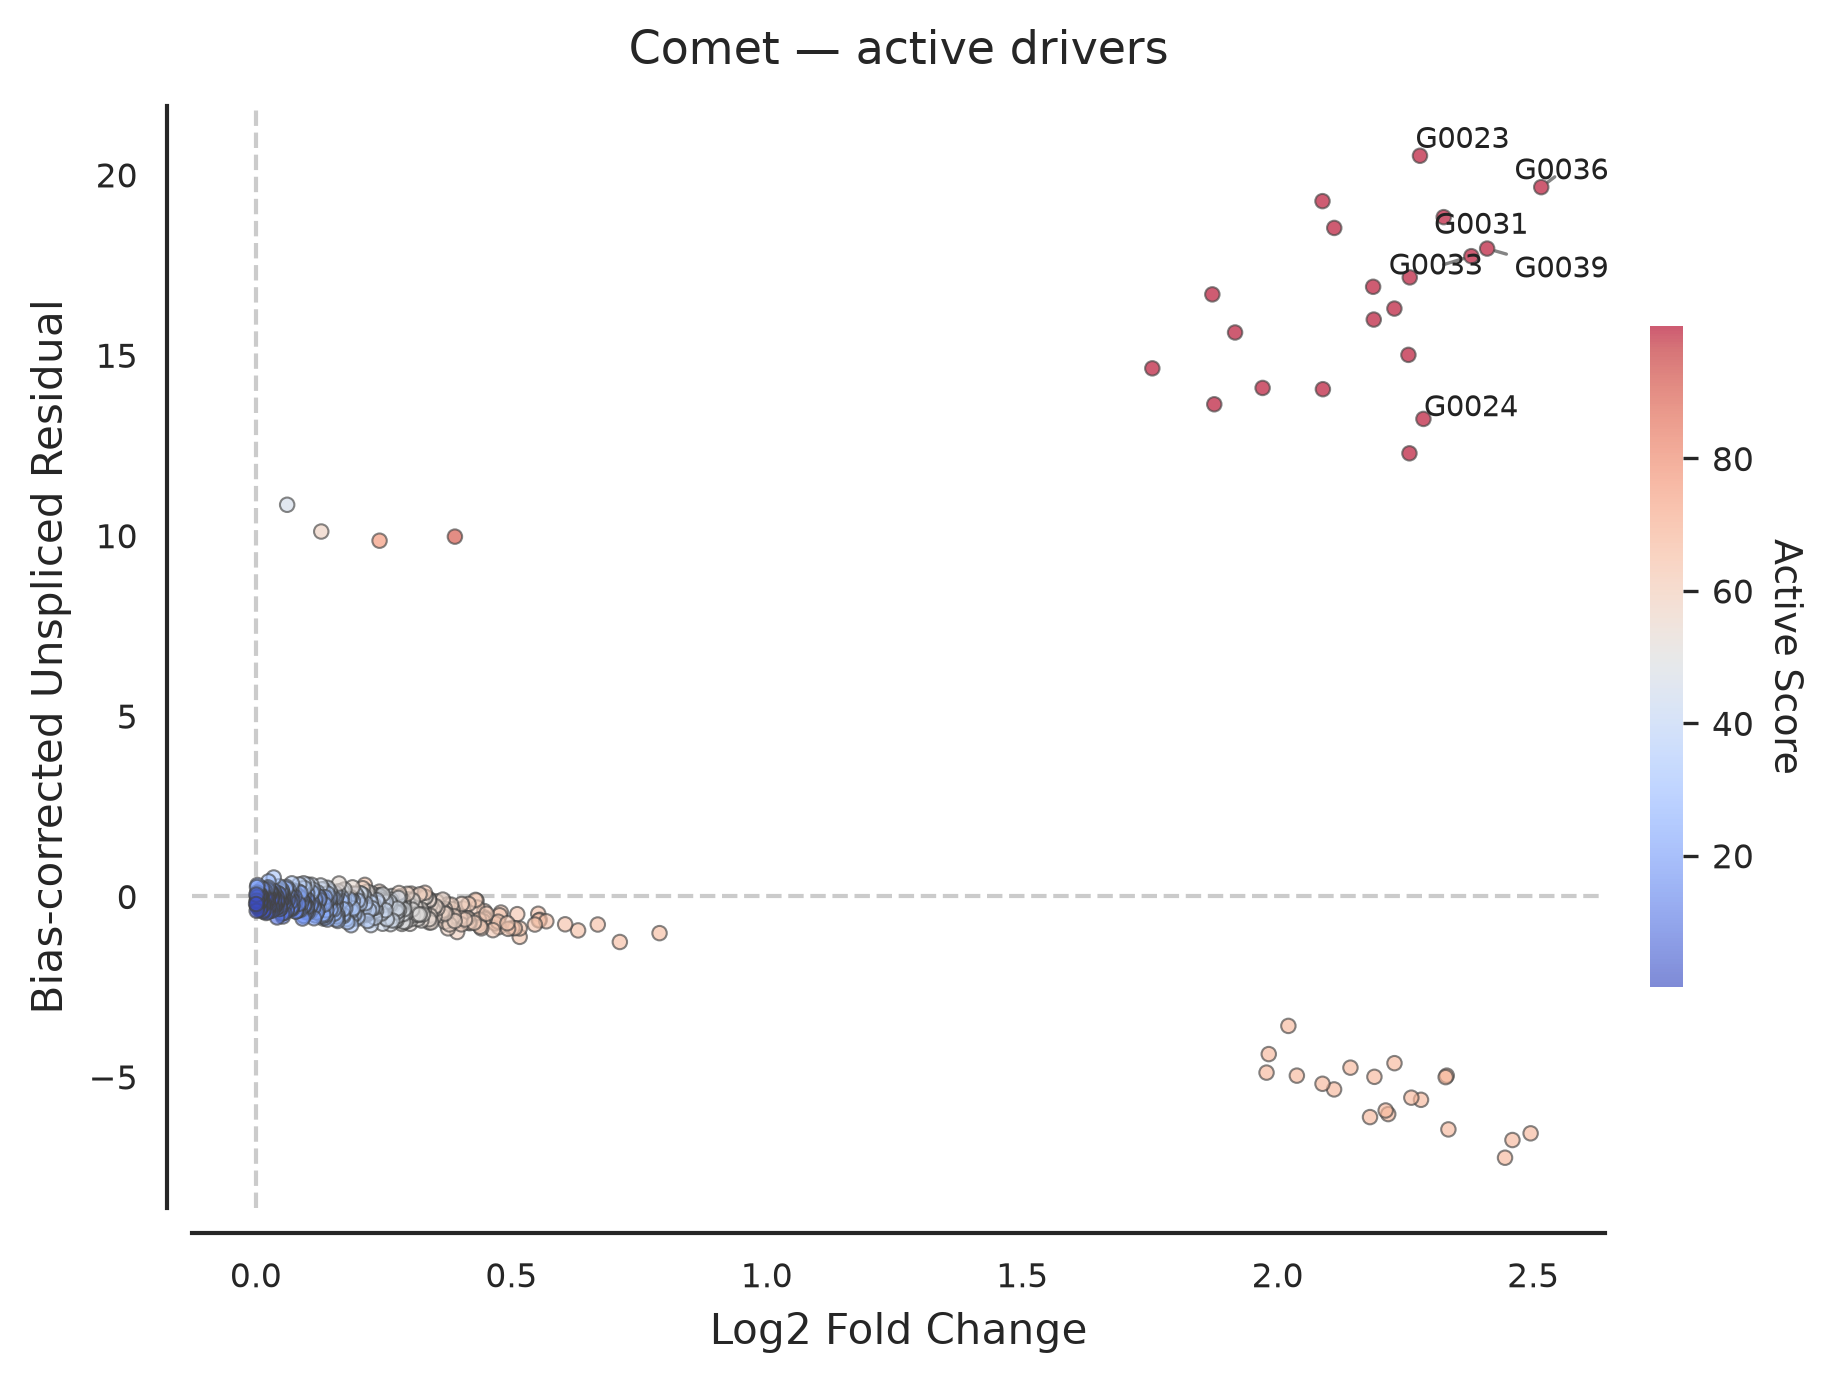

In [5]:
scat.pl.comet_plot(
    all_results,
    top_n=6,
    title="Comet — active drivers",
    s=12,
    alpha=0.65,
    **FS,
    **FIG,
    show=True,
);

**Variant — variable vs fixed point size** (few labels).


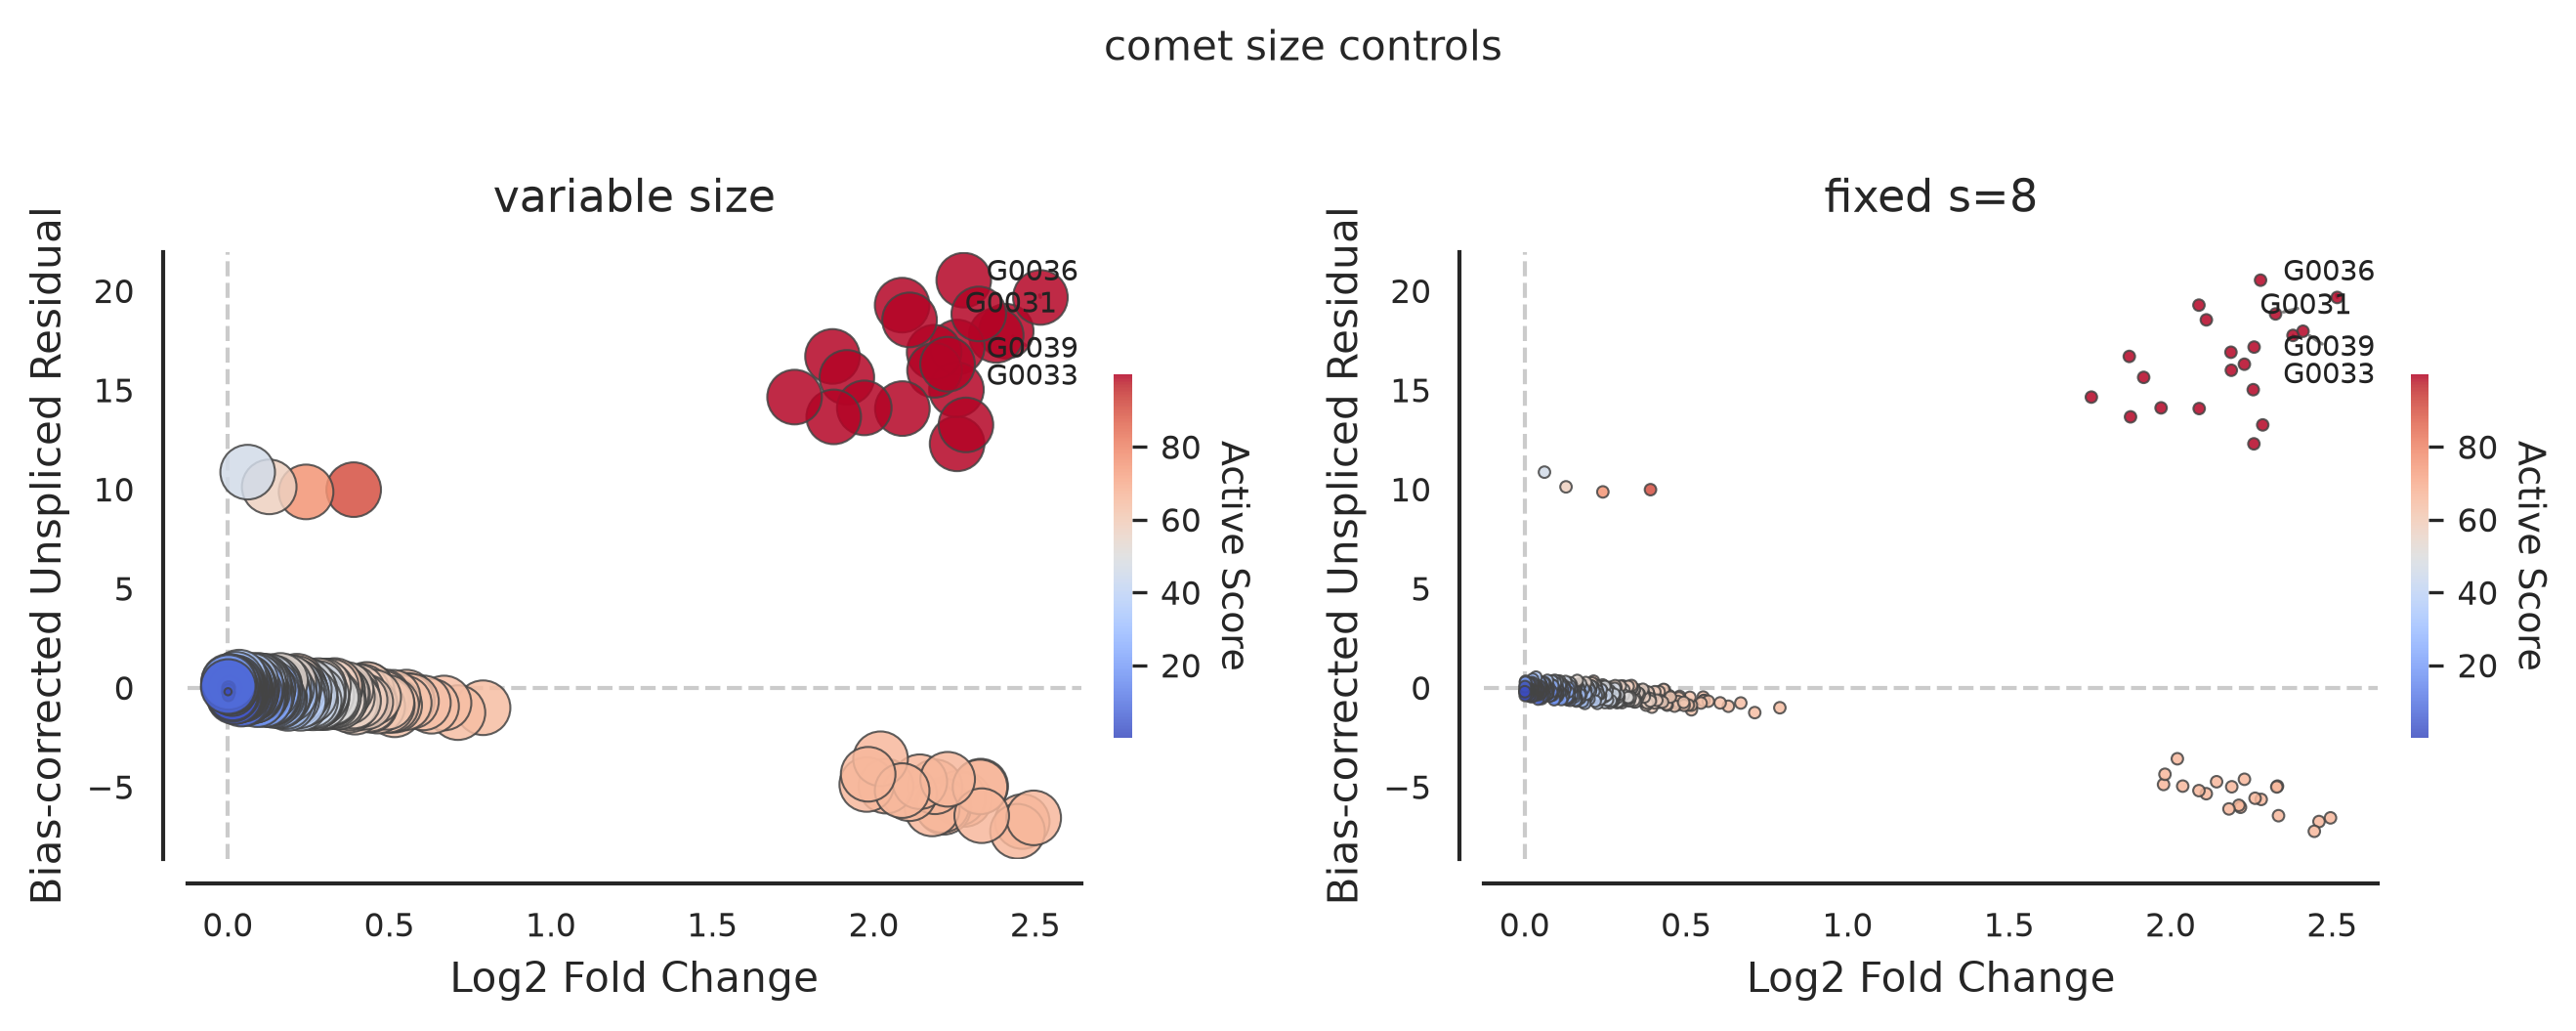

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.4), dpi=150)
scat.pl.comet_plot(
    all_results,
    top_n=4,
    point_scale=0.8,
    title="variable size",
    ax=axes[0],
    show=False,
    **FS,
)
scat.pl.comet_plot(
    all_results,
    top_n=4,
    s=8,
    title="fixed s=8",
    ax=axes[1],
    show=False,
    **FS,
)
fig.suptitle("comet size controls", y=1.02, fontsize=10)
plt.tight_layout()
plt.show()

## 2. Volcano on full `all_results` (two-sided, dense)

**What it answers:** Classical logFC vs −log10(padj) for **all** genes.

**Function**: `scat.pl.volcano_plot`

| Kwarg | Role |
|-------|------|
| `style` | `"ggvolcano"` (teal/orange two-sided), `"auto"`, `"gradual"` |
| `s`, `alpha` | Fixed small points + transparency for dense clouds |
| `top_n`, `label_fontsize` | Keep labels few and small |
| `legend_position` | `"UL"` / `"UR"` / `"DL"` / `"DR"` (ggvolcano) |

:::{tip}
`style="auto"` colors by **active_score** (upregulation-gated) — down genes
are present but visually muted. Use **`ggvolcano`** for a clear two-sided
publication look.
:::


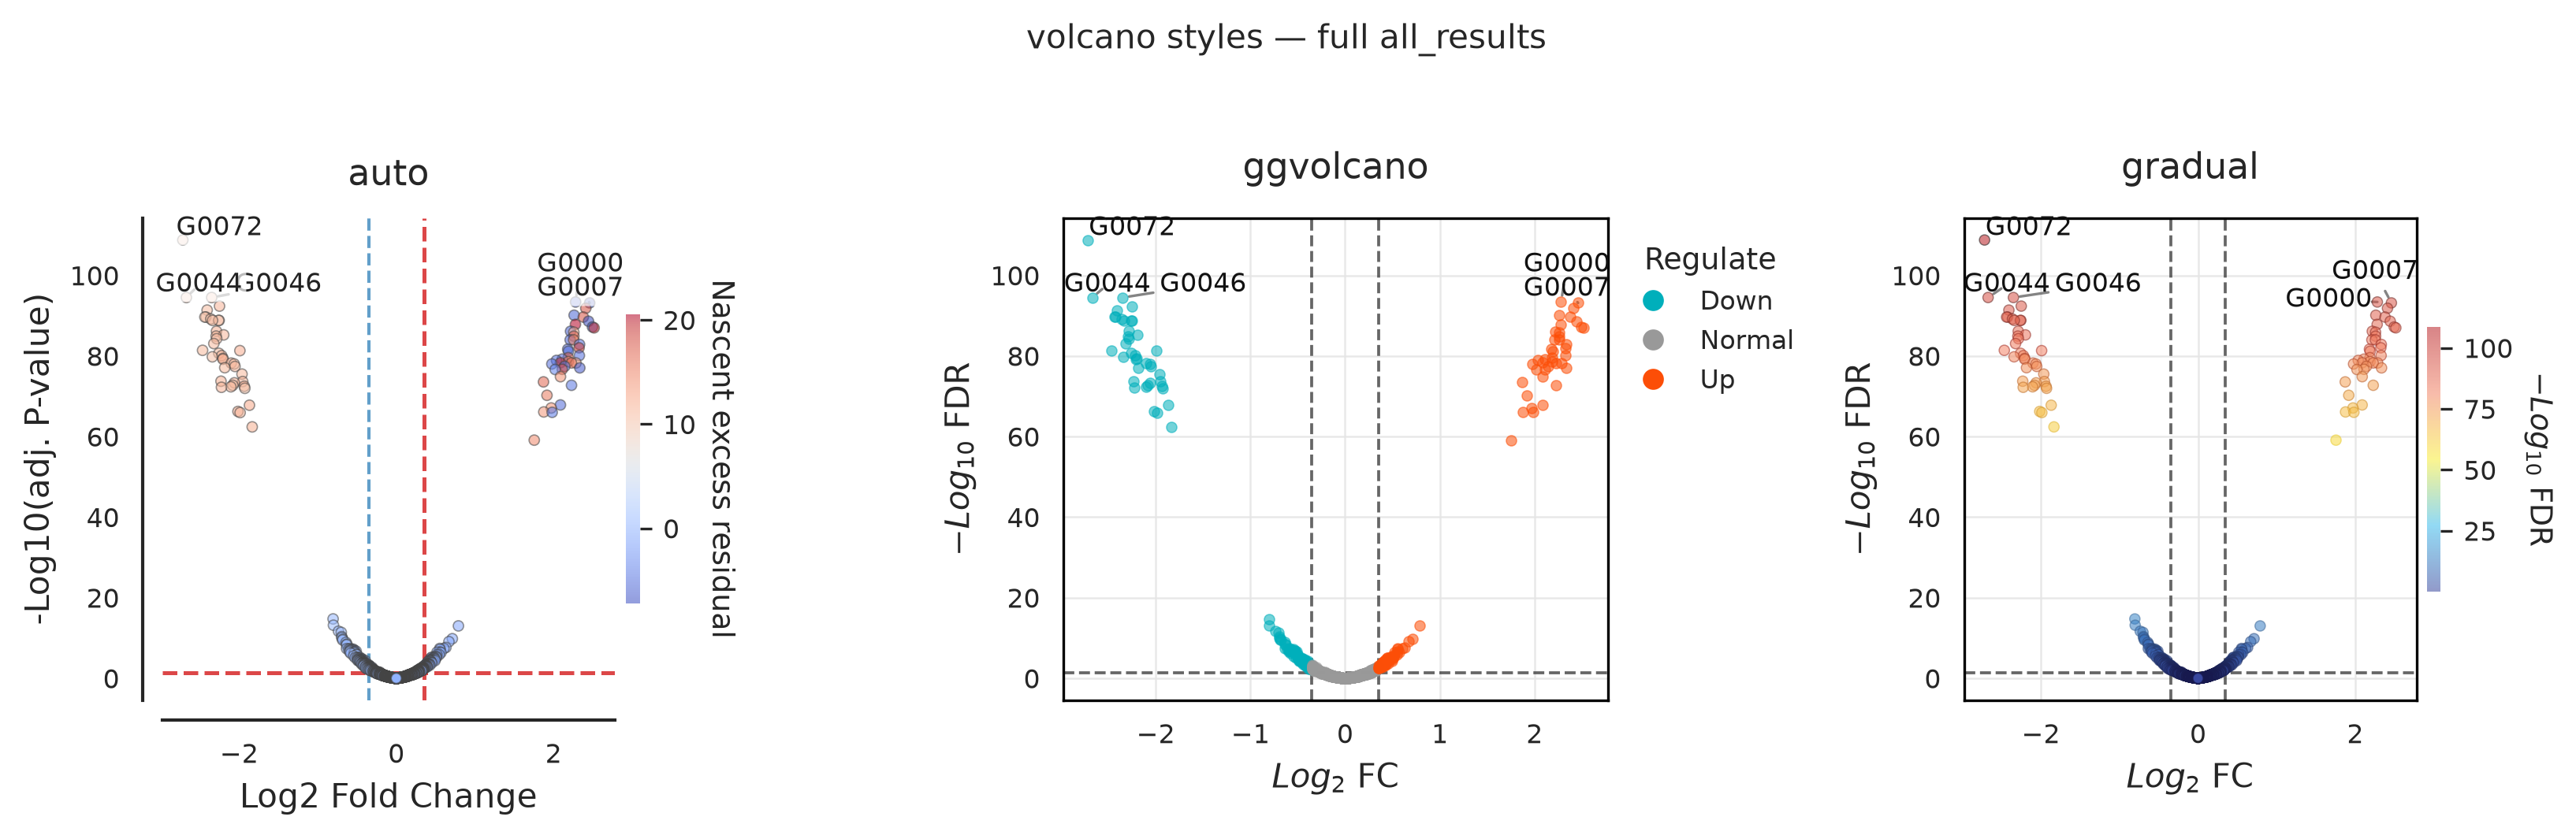

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.4), dpi=150)
for ax, style, title in zip(
    axes,
    ("auto", "ggvolcano", "gradual"),
    ("auto", "ggvolcano", "gradual"),
):
    scat.pl.volcano_plot(
        all_results,
        style=style,
        title=title,
        ax=ax,
        show=False,
        **VOLC,
    )
fig.suptitle("volcano styles — full all_results", y=1.03, fontsize=10)
plt.tight_layout()
plt.show()

**Variant — force-label a few genes** (still full table).


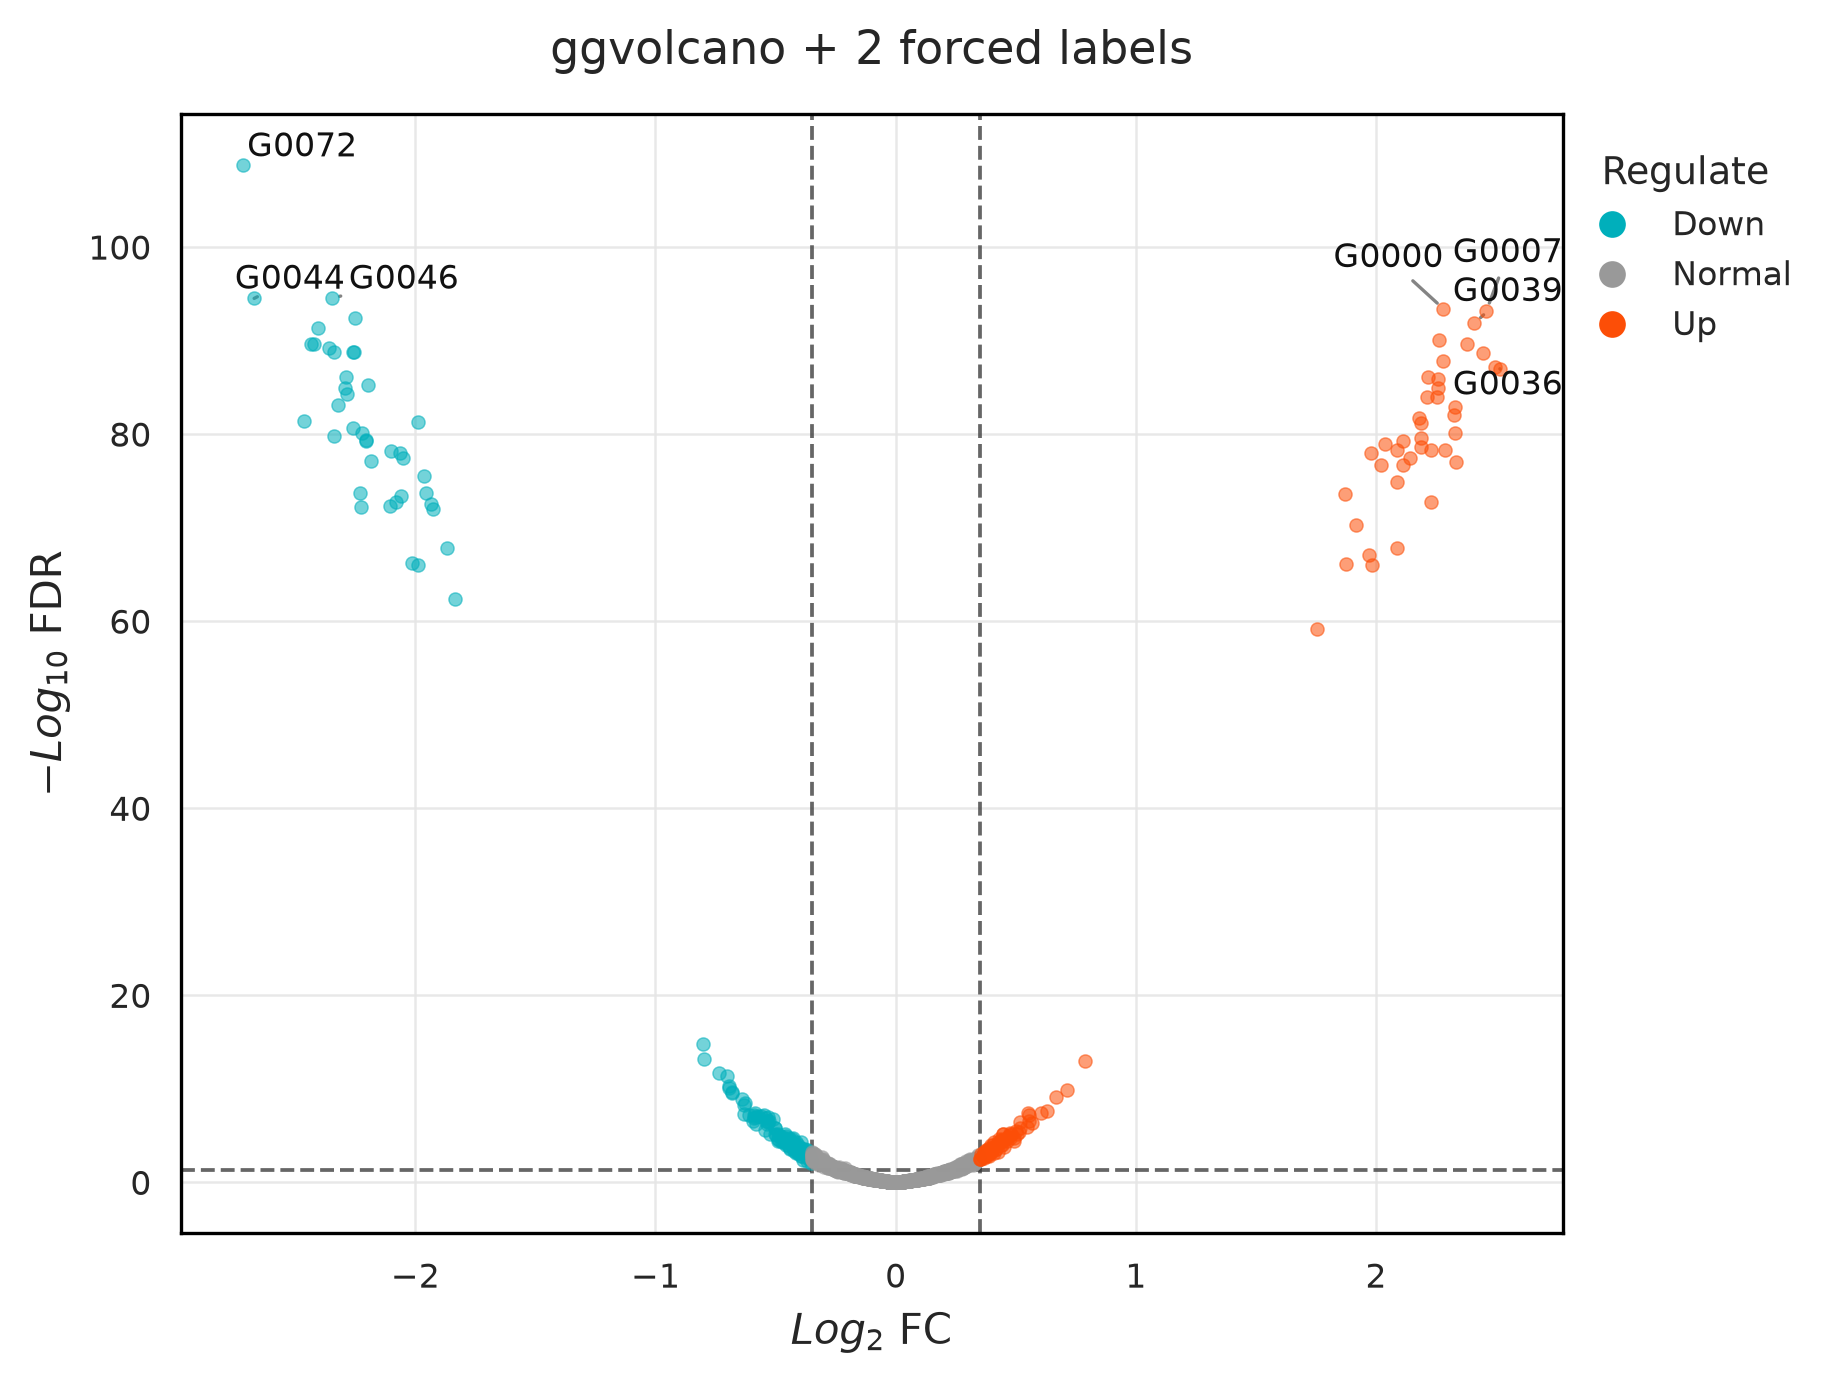

In [8]:
scat.pl.volcano_plot(
    all_results,
    style="ggvolcano",
    label_genes=list(top_genes[:2]),
    title="ggvolcano + 2 forced labels",
    show=True,
    **VOLC,
);

**Variant — point size and color**

Size:

| Kwarg | Effect |
|-------|--------|
| `s=` | Fixed size for every gene (simplest for dense clouds) |
| `point_scale` / `min_size` / `max_size` | Variable size (usually by score or −log10 padj when `s` is omitted) |
| `alpha` | Transparency |

Color:

| Kwarg | Effect |
|-------|--------|
| `style="auto"` + `color_by=` + `cmap=` | Continuous coloring (default `color_by="active_score"`) |
| `style="ggvolcano"` + `fills=` / `colors=` | Discrete Down / Normal / Up palette (3 hex colors each) |
| `style="gradual"` | Size and color track −log10(FDR) |


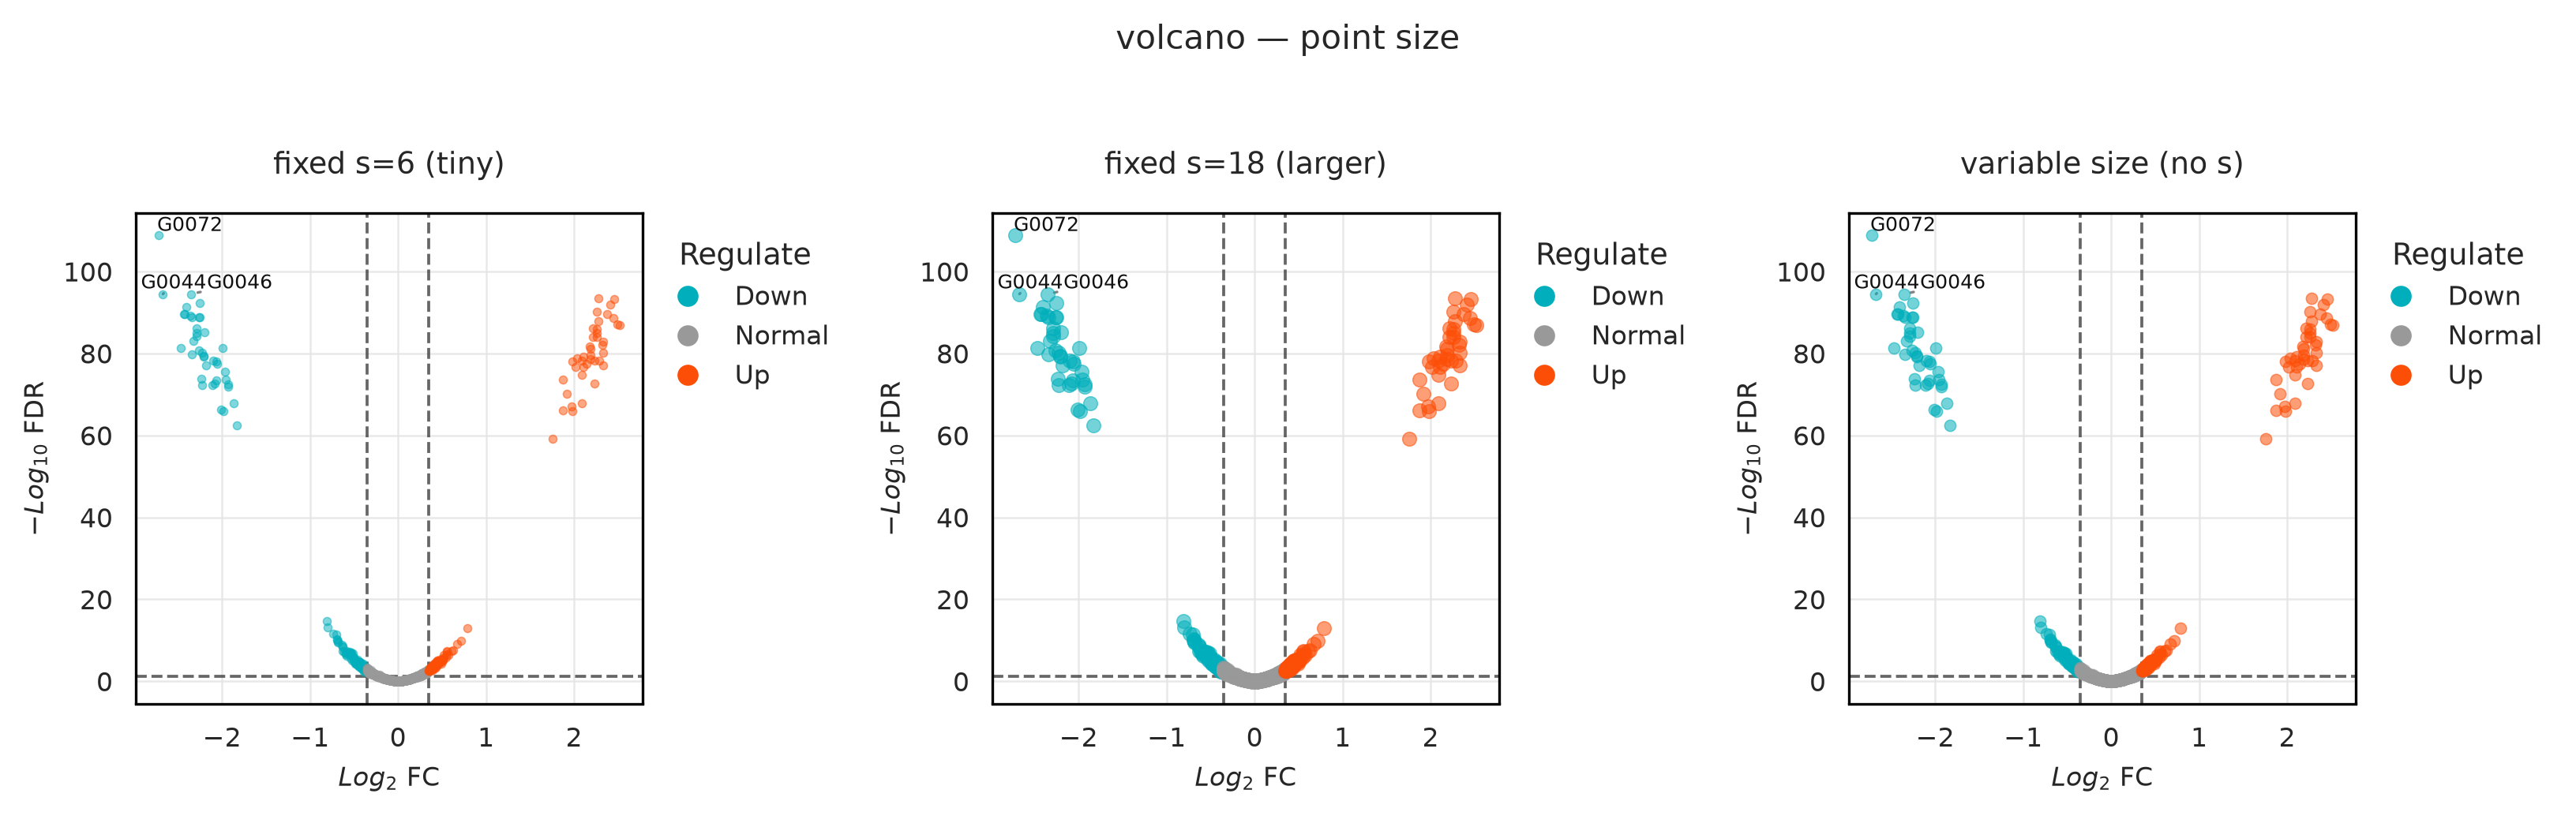

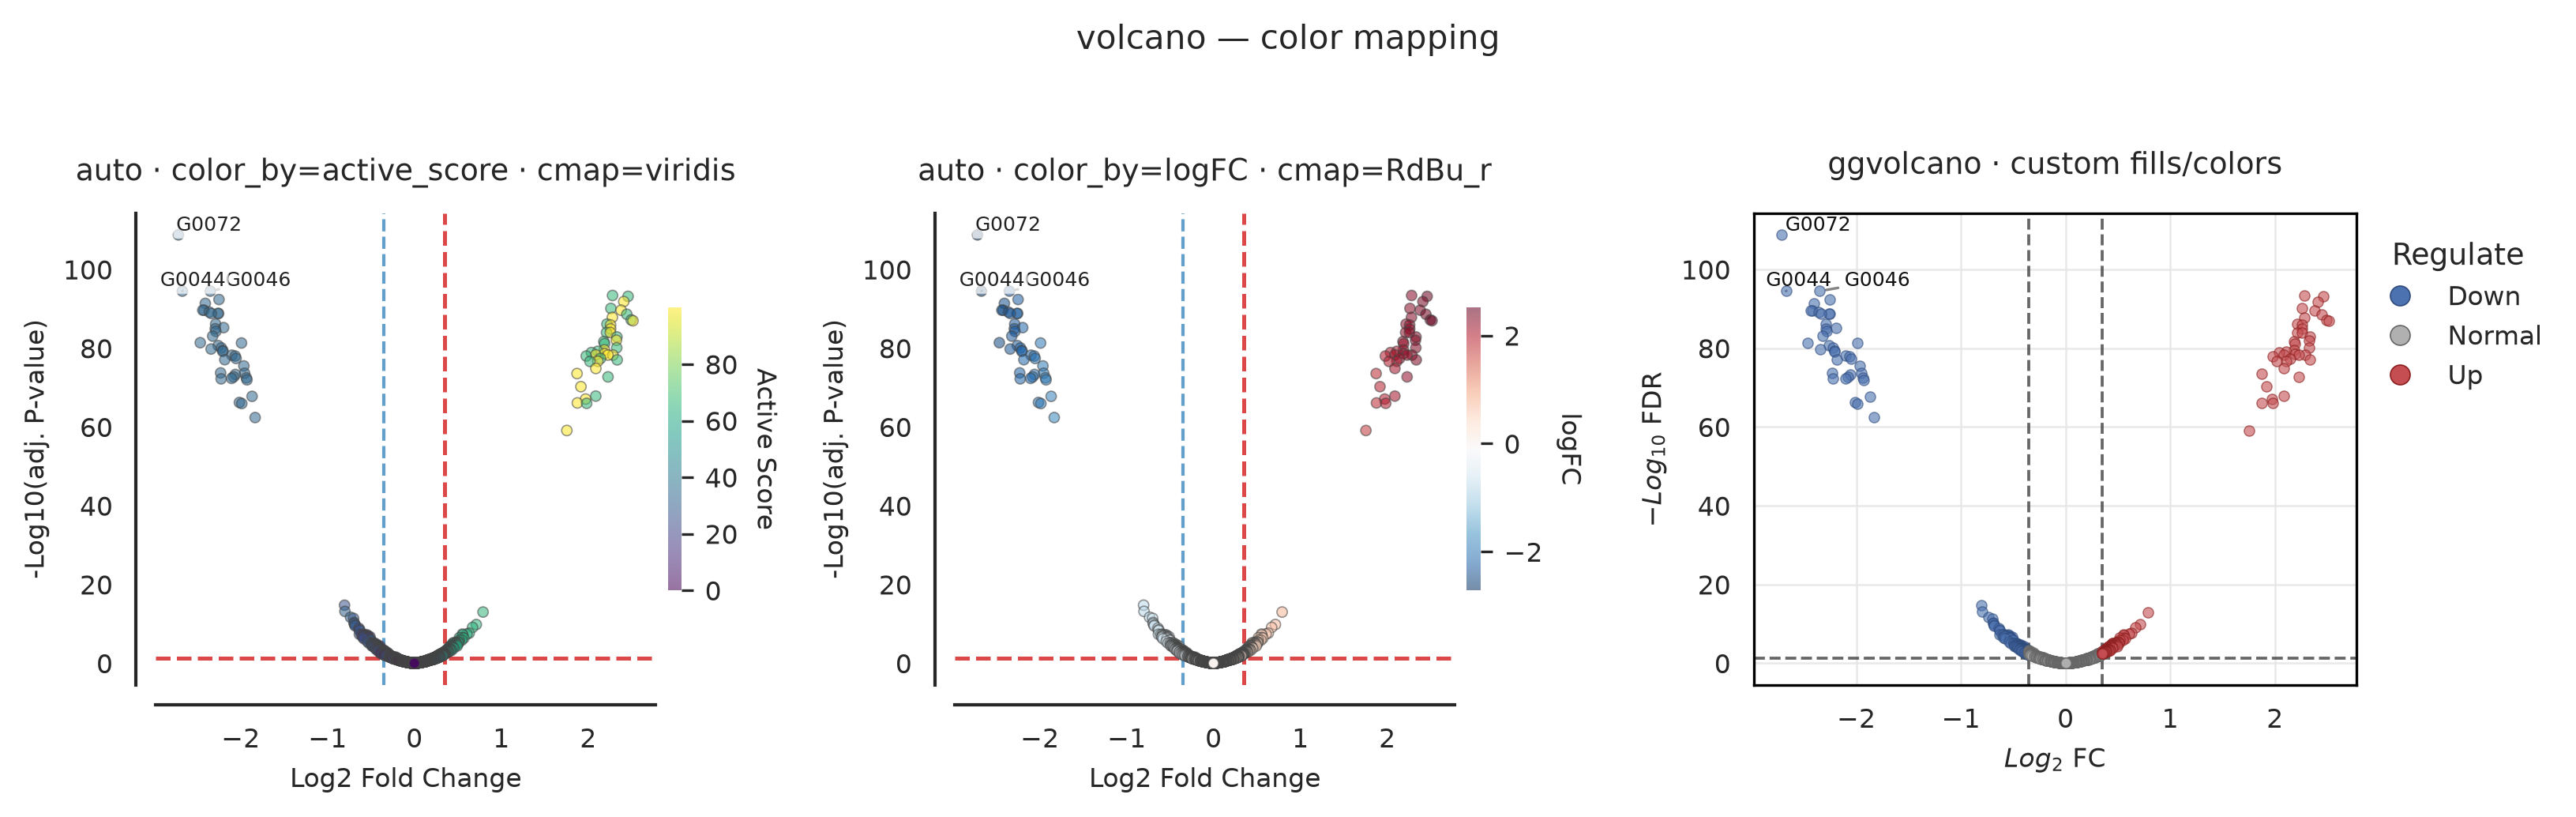

In [9]:
# Row 1: size controls (ggvolcano, same palette)
fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.3), dpi=150)
size_specs = [
    {"s": 6, "alpha": 0.5, "title": "fixed s=6 (tiny)"},
    {"s": 18, "alpha": 0.55, "title": "fixed s=18 (larger)"},
    {
        "s": None,
        "point_scale": 1.2,
        "min_size": 4,
        "max_size": 80,
        "alpha": 0.55,
        "title": "variable size (no s)",
    },
]
for ax, kw in zip(axes, size_specs):
    scat.pl.volcano_plot(
        all_results,
        style="ggvolcano",
        top_n=3,
        logfc_cutoff=0.35,
        pval_cutoff=0.05,
        legend_position="UR",
        fontsize=8,
        label_fontsize=6,
        figsize=(5, 3.5),
        dpi=150,
        ax=ax,
        show=False,
        **kw,
    )
fig.suptitle("volcano — point size", y=1.03, fontsize=10)
plt.tight_layout()
plt.show()

# Row 2: color controls
fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.3), dpi=150)
# continuous active_score
scat.pl.volcano_plot(
    all_results,
    style="auto",
    color_by="active_score",
    cmap="viridis",
    s=10,
    alpha=0.55,
    top_n=3,
    logfc_cutoff=0.35,
    pval_cutoff=0.05,
    title="auto · color_by=active_score · cmap=viridis",
    fontsize=8,
    label_fontsize=6,
    ax=axes[0],
    show=False,
)
# continuous -log10 p via p_adj column still uses score path; color by logFC magnitude
scat.pl.volcano_plot(
    all_results,
    style="auto",
    color_by="logFC",
    cmap="RdBu_r",
    s=10,
    alpha=0.55,
    top_n=3,
    logfc_cutoff=0.35,
    pval_cutoff=0.05,
    title="auto · color_by=logFC · cmap=RdBu_r",
    fontsize=8,
    label_fontsize=6,
    ax=axes[1],
    show=False,
)
# custom ggvolcano palette (Down, Normal, Up)
scat.pl.volcano_plot(
    all_results,
    style="ggvolcano",
    fills=("#4C72B0", "#B0B0B0", "#C44E52"),
    colors=("#2F4B7C", "#666666", "#8B1E1E"),
    s=10,
    alpha=0.6,
    top_n=3,
    logfc_cutoff=0.35,
    pval_cutoff=0.05,
    legend_position="UR",
    title="ggvolcano · custom fills/colors",
    fontsize=8,
    label_fontsize=6,
    ax=axes[2],
    show=False,
)
fig.suptitle("volcano — color mapping", y=1.03, fontsize=10)
plt.tight_layout()
plt.show()

## 3. Rank plot and 3D volcano

**Functions**: `active_score_rankplot`, `volcano_3d`


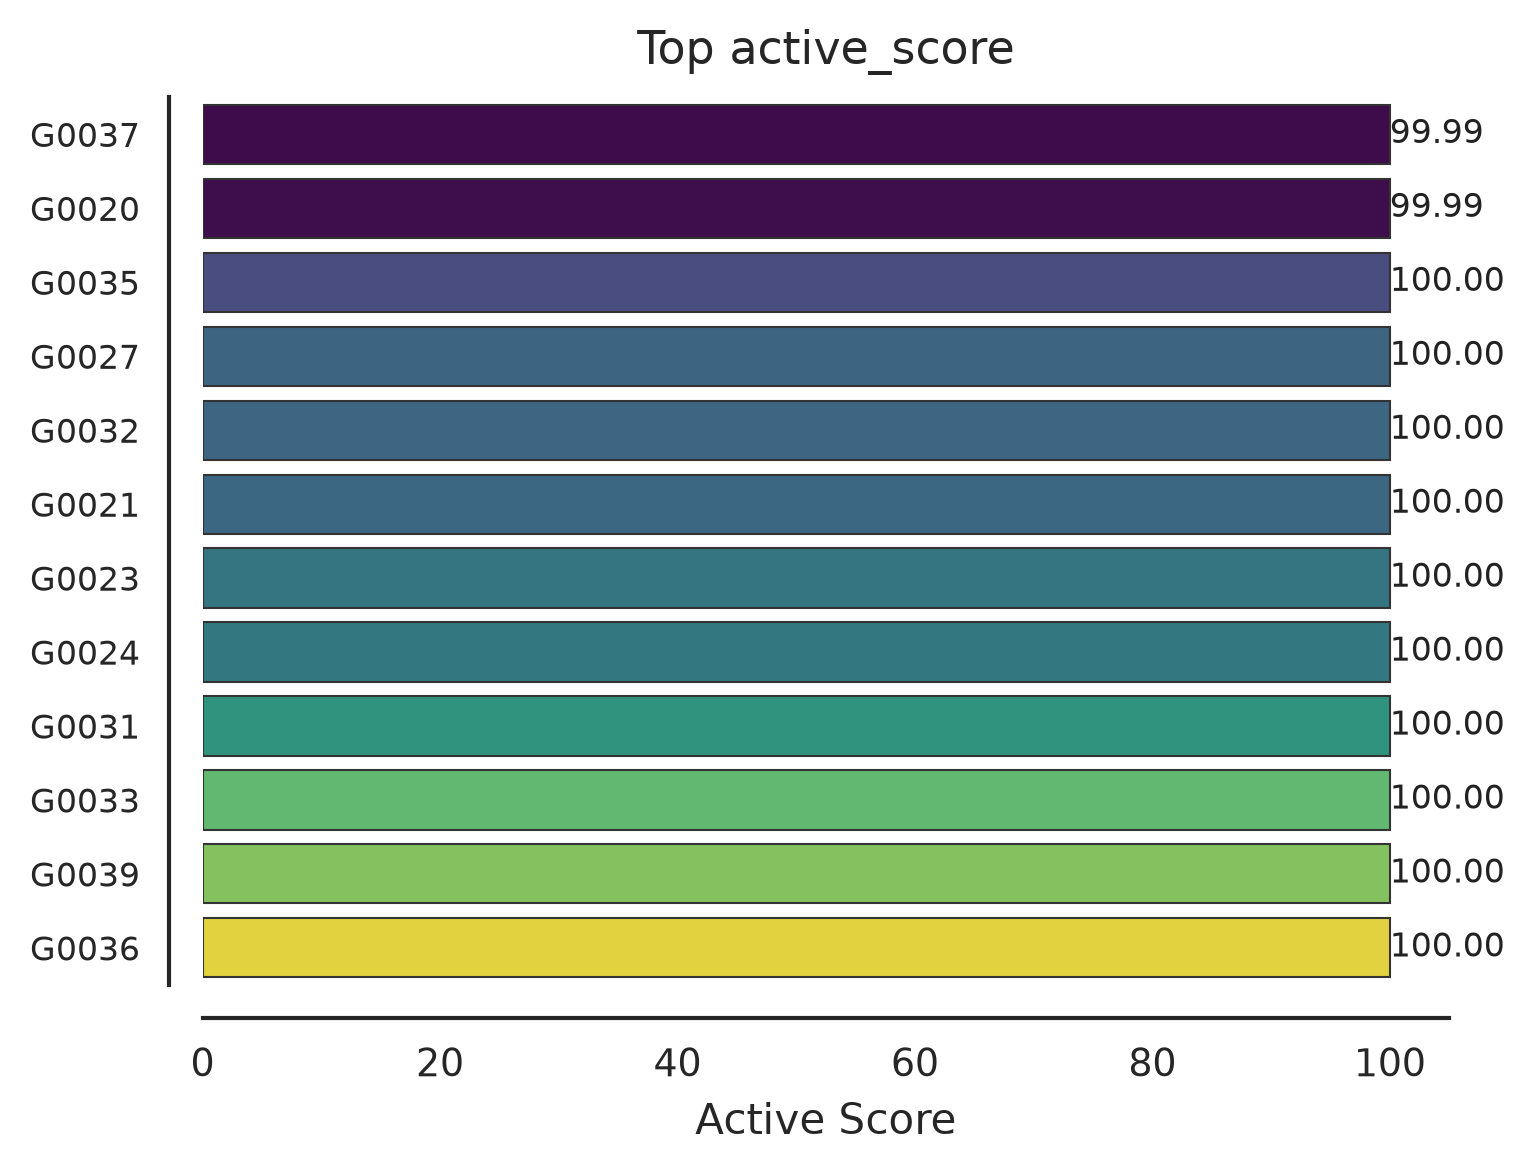

In [10]:
scat.pl.active_score_rankplot(
    all_results,
    top_n=12,
    title="Top active_score",
    figsize=(5.0, 3.8),
    dpi=150,
    show=True,
);

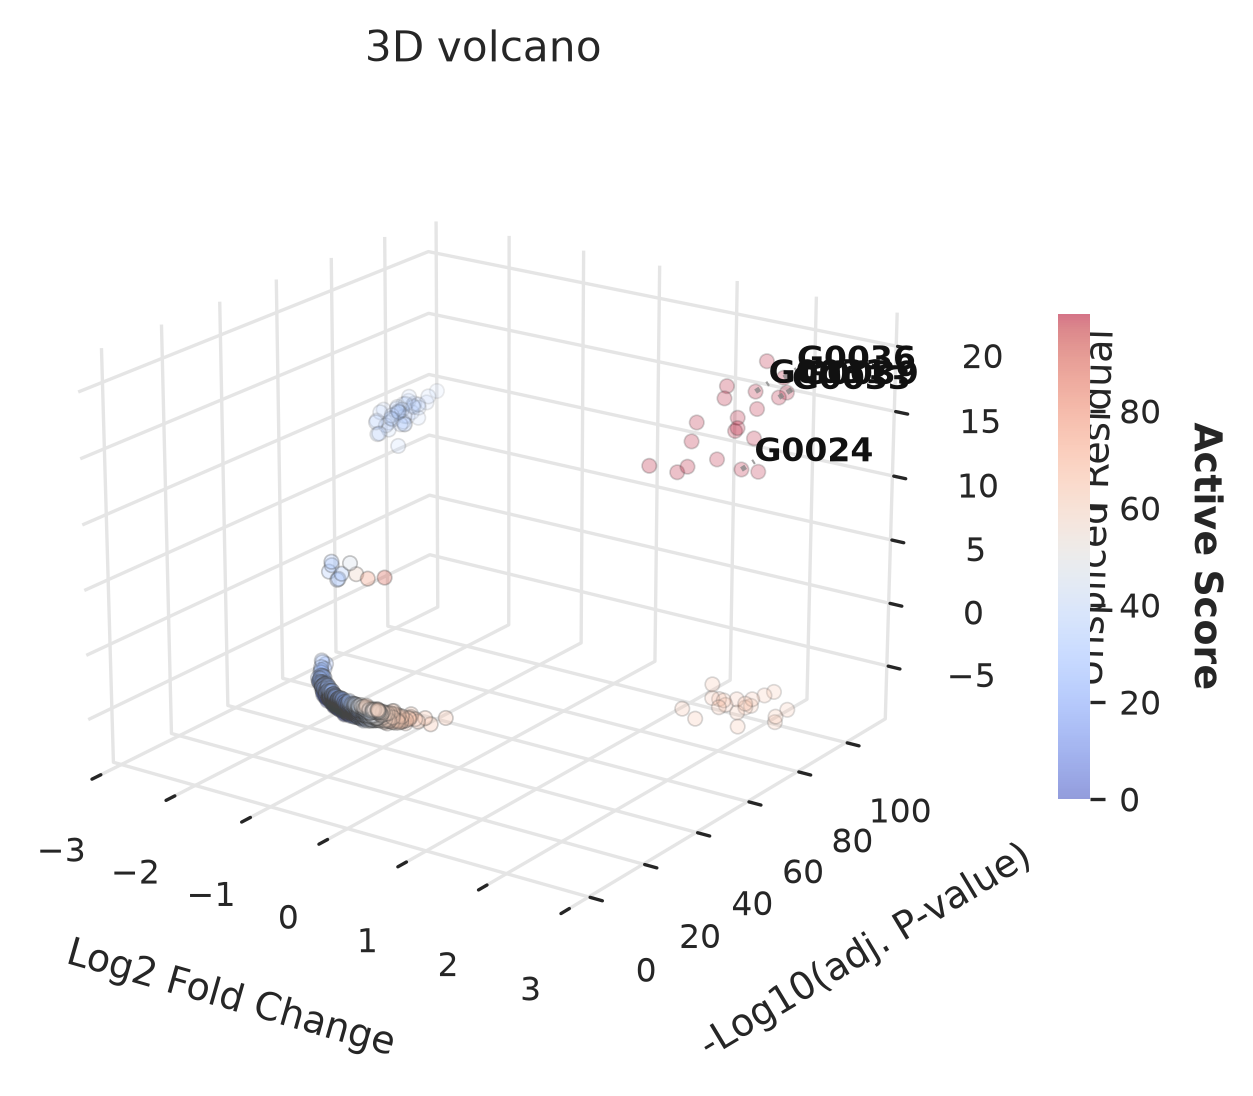

In [11]:
scat.pl.volcano_3d(
    all_results,
    top_n=5,
    s=12,
    alpha=0.55,
    title="3D volcano",
    figsize=(5.2, 4.2),
    dpi=150,
    fontsize=9,
    show=True,
);

## 4. Diagnostics

**Functions**: `bias_diagnostic_plot`, `gamma_shrinkage_plot`


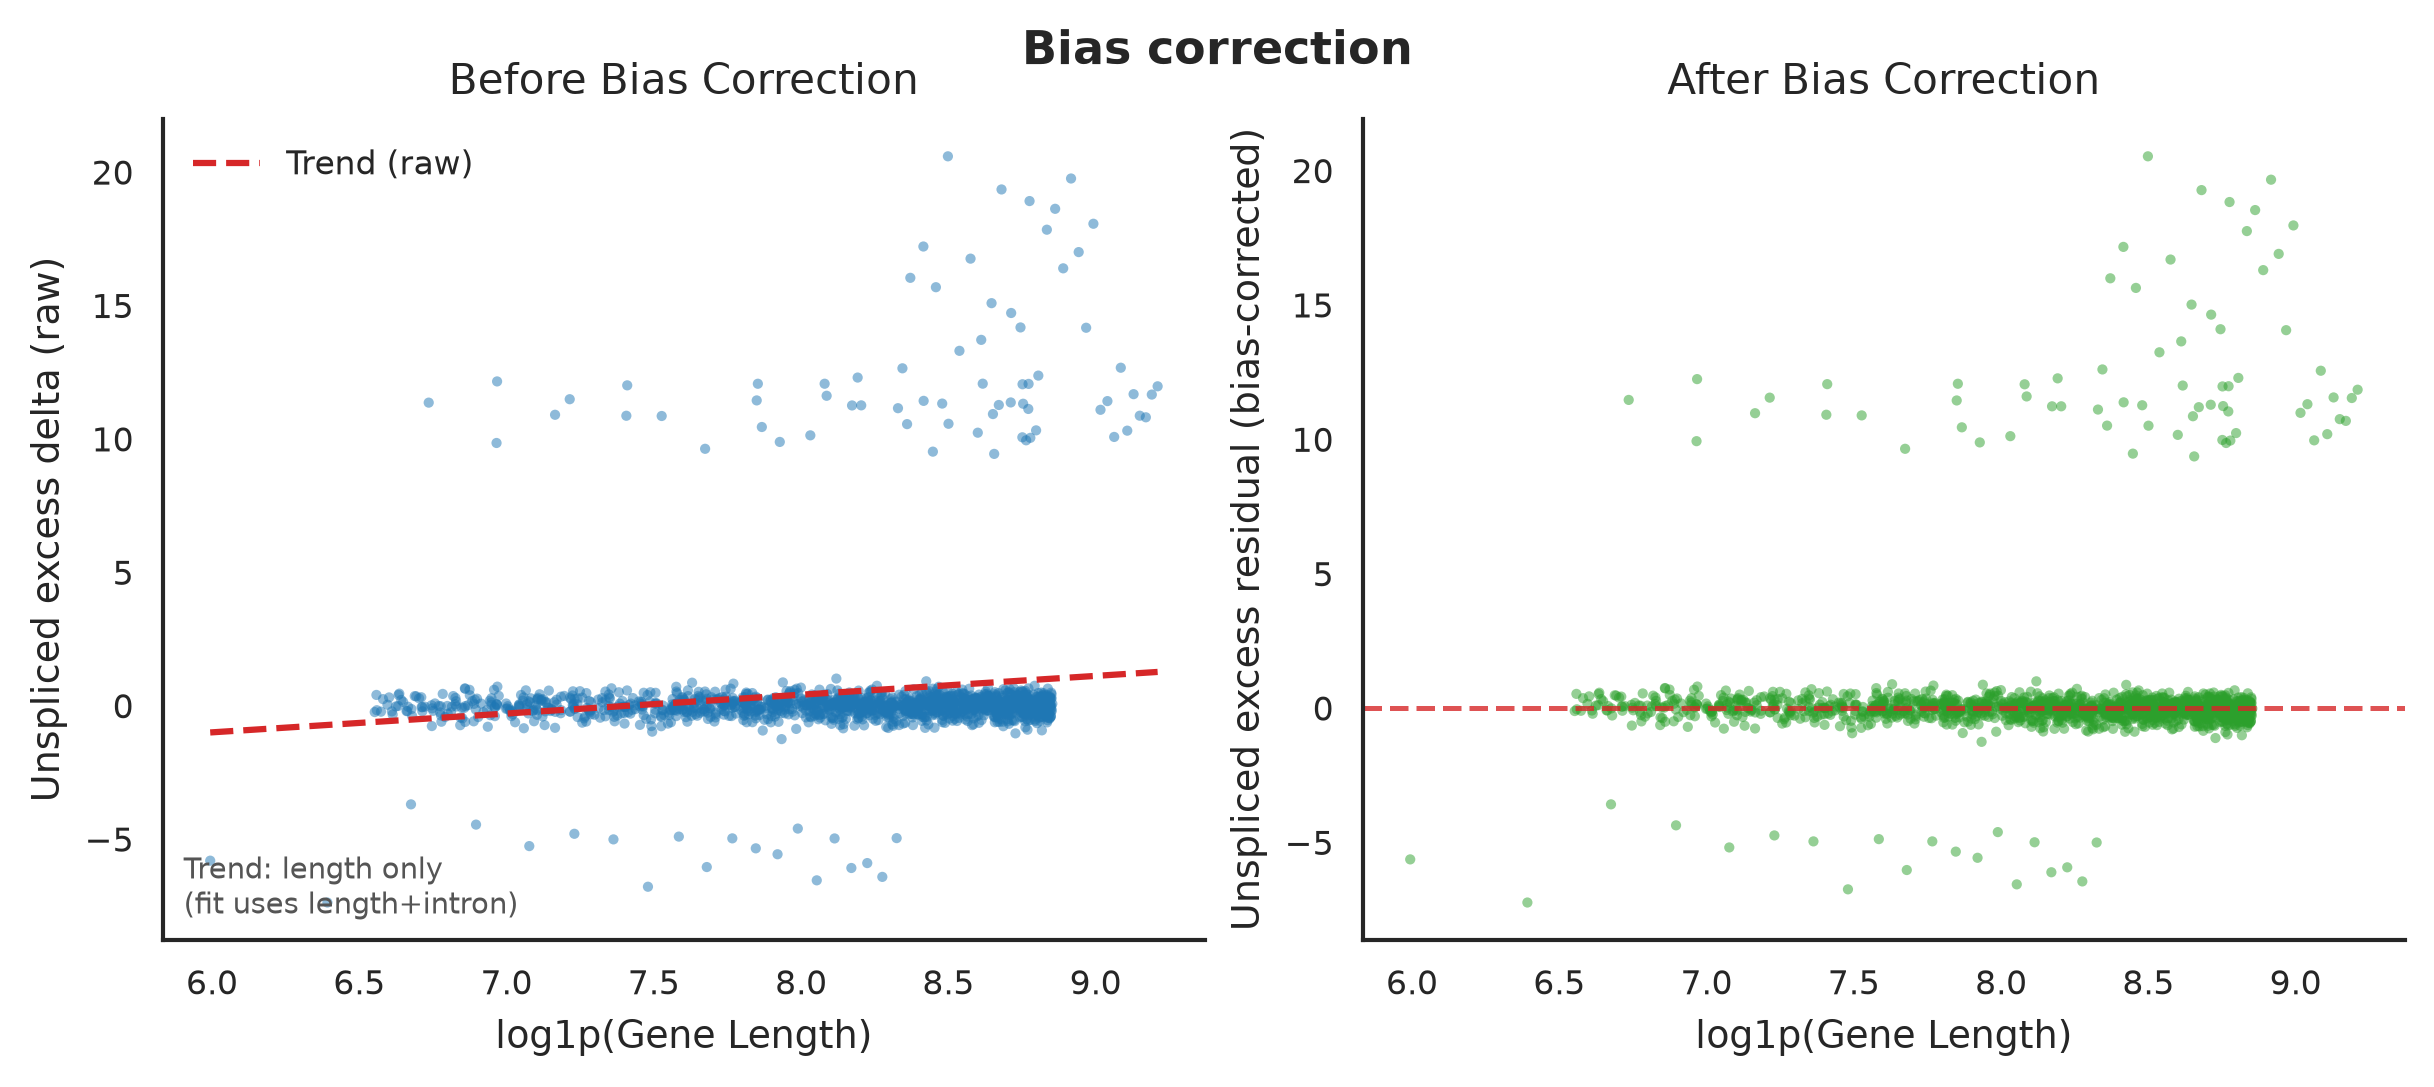

In [12]:
scat.pl.bias_diagnostic_plot(
    all_results,
    title="Bias correction",
    point_size=6,
    figsize=(8.0, 3.4),
    dpi=150,
    fontsize=9,
    show=True,
);

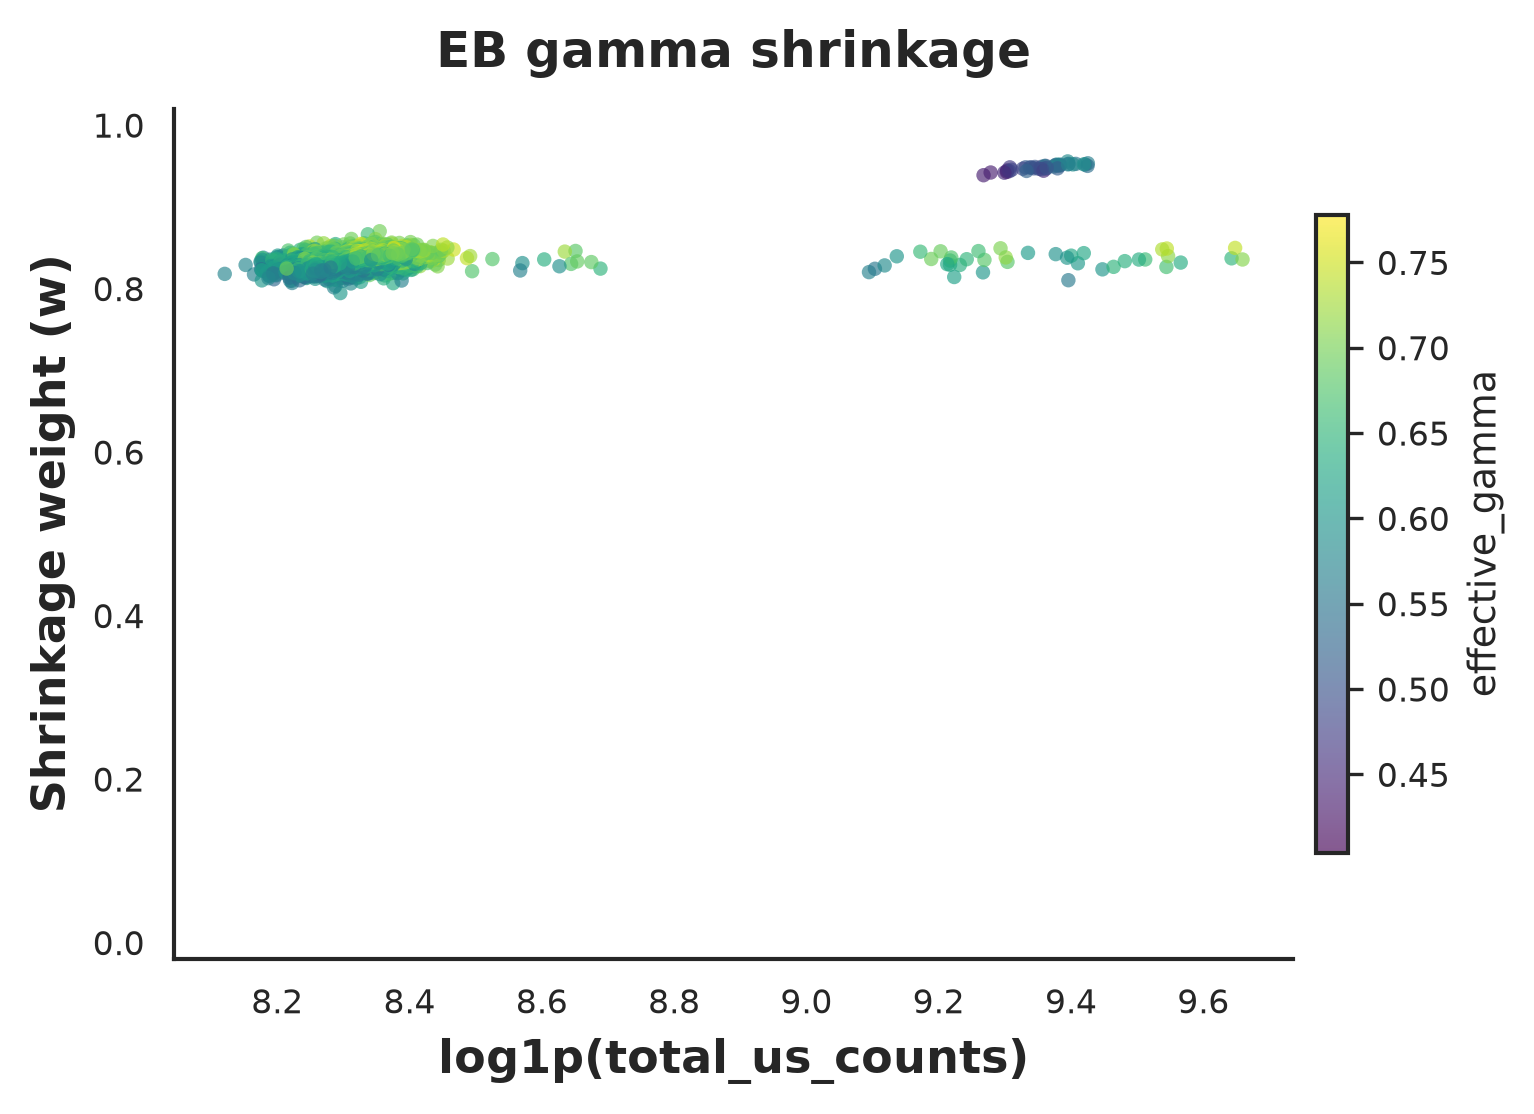

In [13]:
scat.pl.gamma_shrinkage_plot(
    all_results,
    title="EB gamma shrinkage",
    figsize=(5.0, 3.6),
    dpi=150,
    show=True,
);

## 5. Phase portraits and heatmap

**Functions**: `velocity_phase_portraits`, `active_genes_heatmap`


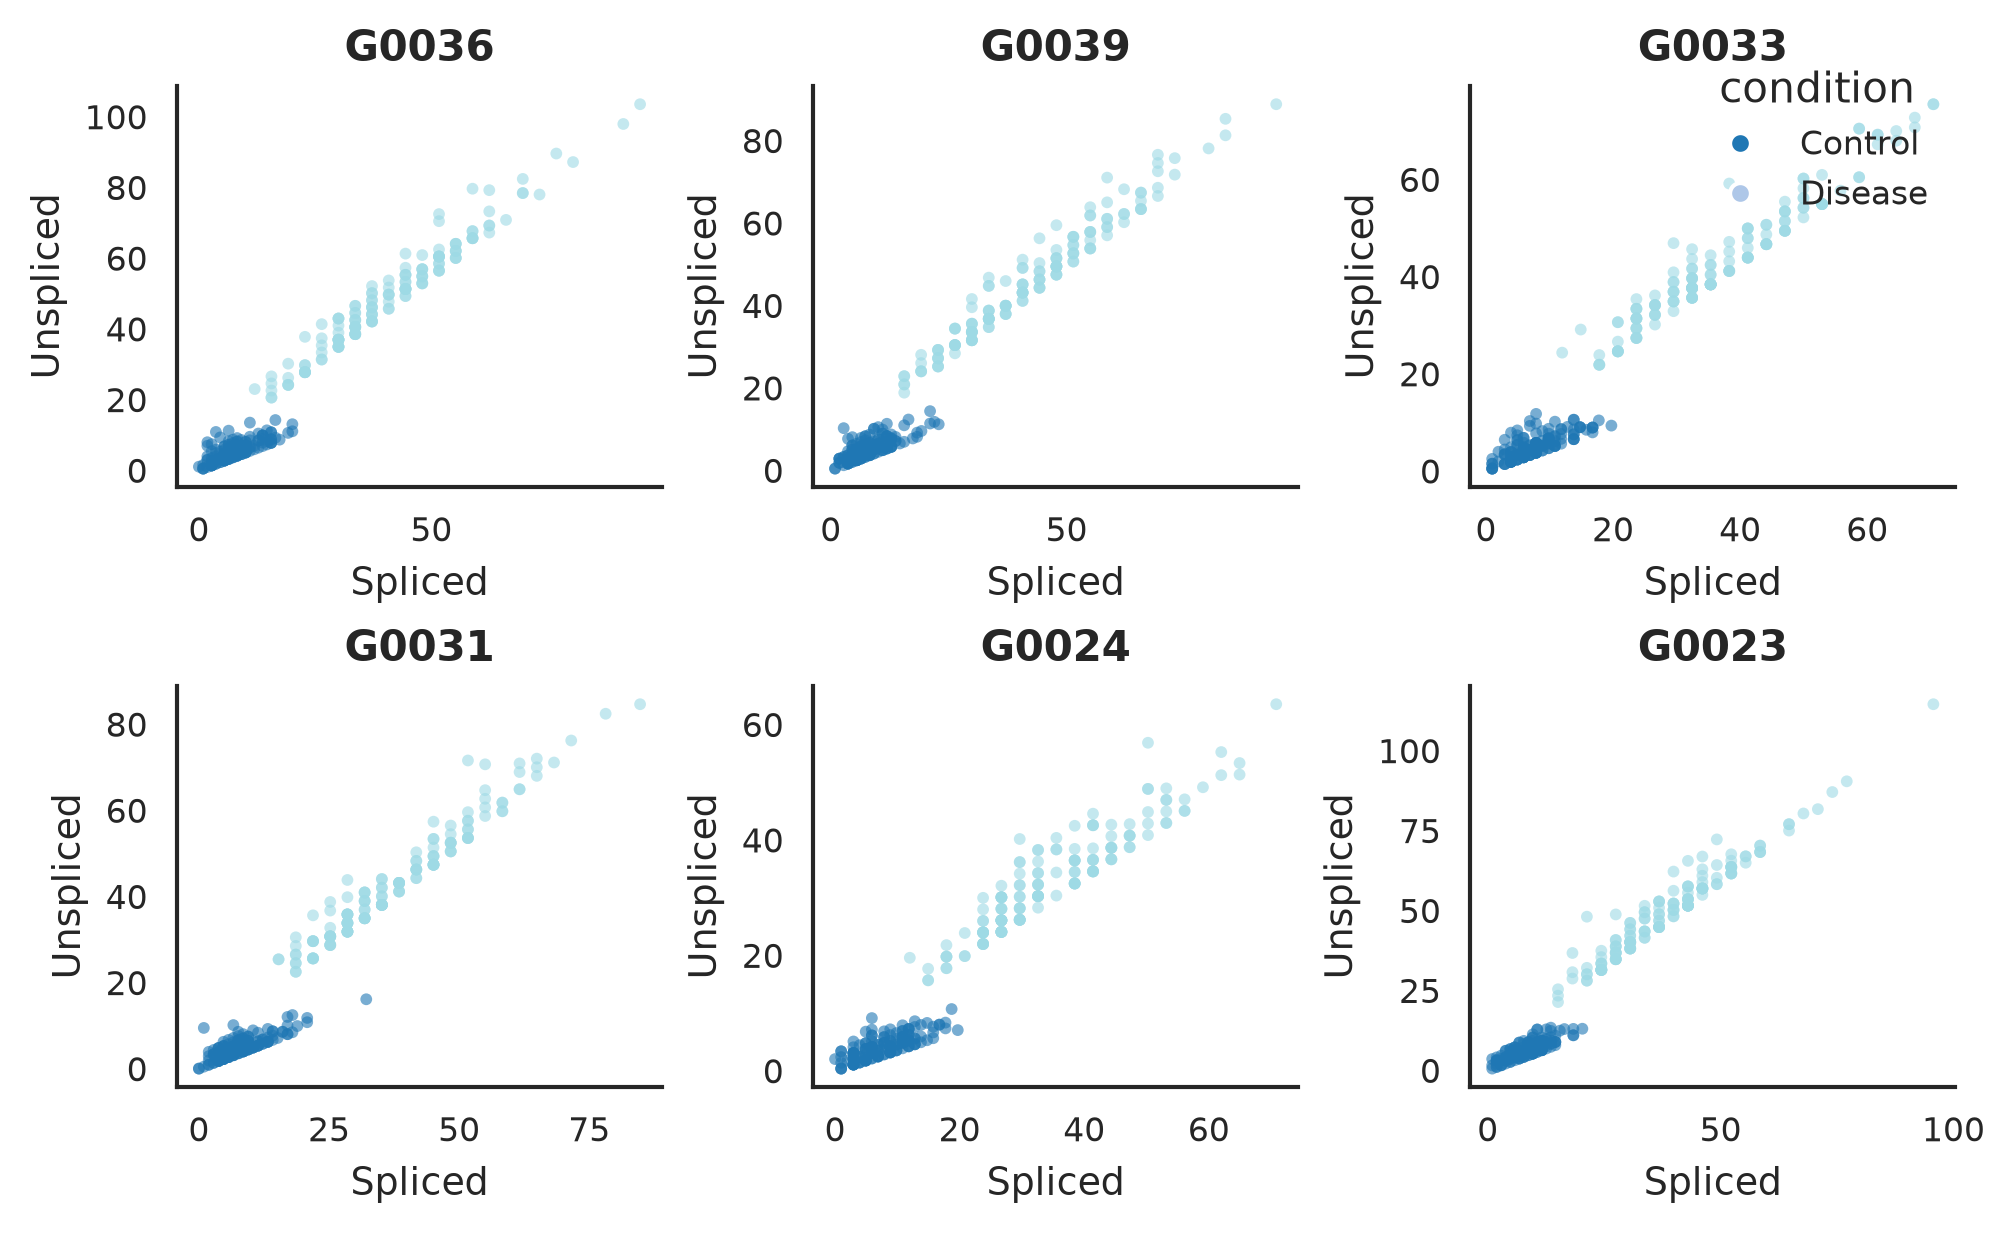

In [14]:
scat.pl.velocity_phase_portraits(
    adata_res,
    genes=top_genes,
    groupby="condition",
    max_genes=6,
    figsize_per_gene=(2.2, 2.0),
    dpi=150,
    show=True,
);

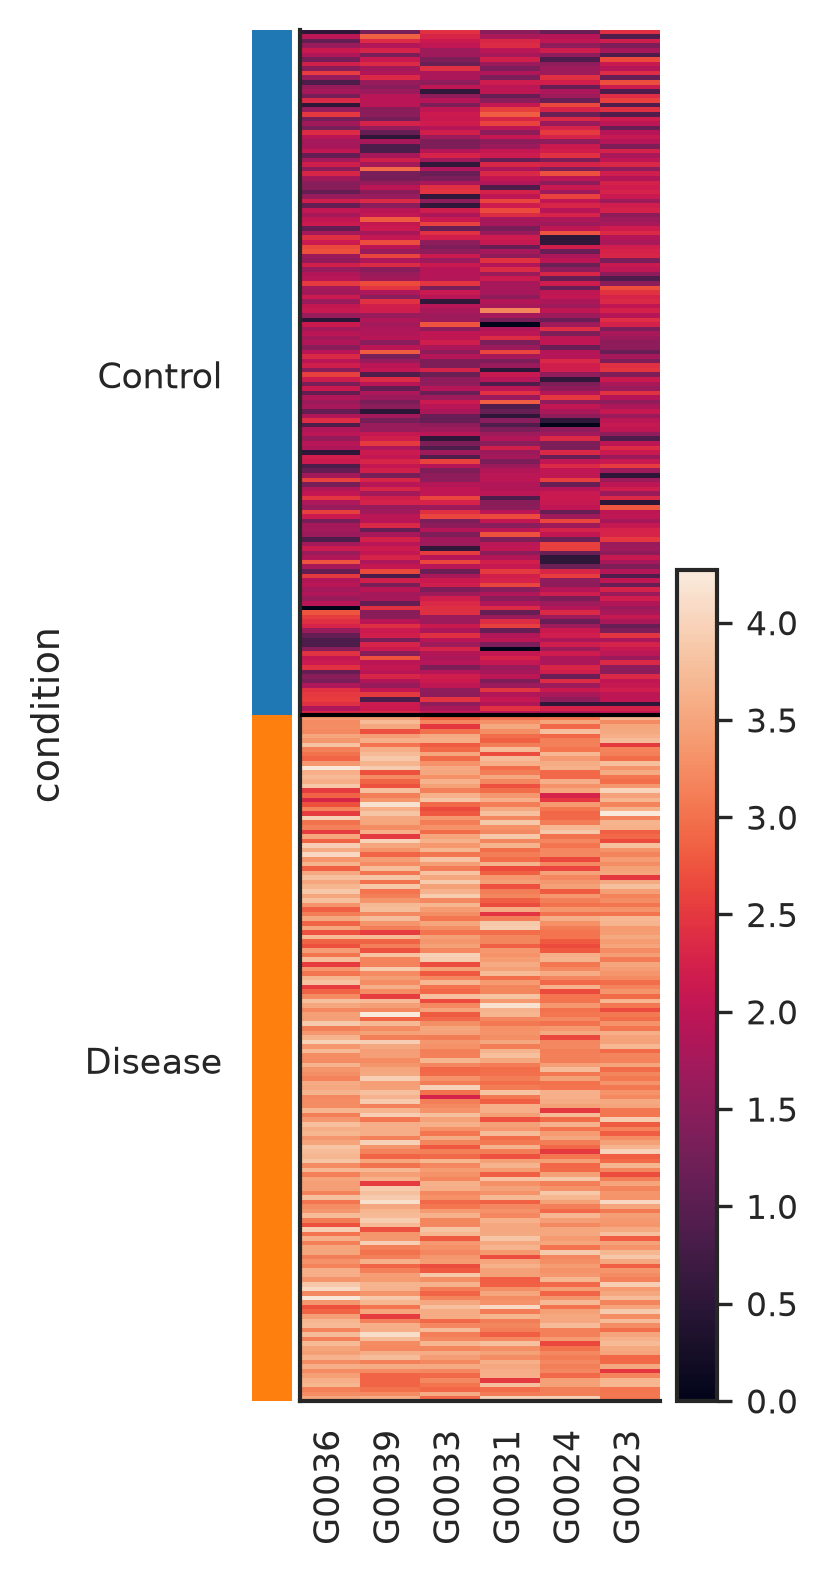

In [15]:
scat.pl.active_genes_heatmap(
    adata_res,
    genes=top_genes,
    groupby="condition",
    show=True,
);

## 6. Enrichment and **multi-group comparison**

Mock ORA tables for three clusters (`up`, `down`, `shared`) so **UpSet** and
**Venn** show multi-set overlap (the usual “compare enrichment across gene
lists” view). Offline — no gene-set download.


In [16]:
def _mock_enrich(
    cluster: str, terms: list[str], sign: float = 1.0, padj0: float = 0.001
) -> pd.DataFrame:
    rows = []
    for i, t in enumerate(terms):
        rows.append(
            {
                "Term": t,
                "Description": t.replace("_", " "),
                "Cluster": cluster,
                "p.adjust": padj0 * (i + 1),
                "GeneRatio": f"{14 - i}/100",
                "BgRatio": "50/5000",
                "Count": int(14 - i),
                "FoldEnrichment": float(3.5 - 0.1 * i),
                "geneID": "/".join(genes[:5]),
                "NES": float(sign * (2.0 - 0.07 * i)),
            }
        )
    return pd.DataFrame(rows)


# Overlapping term sets → non-trivial UpSet / Venn
terms_up = [f"UP_path_{i}" for i in range(1, 8)] + [f"SHARED_{i}" for i in range(1, 5)]
terms_down = [f"DN_path_{i}" for i in range(1, 7)] + [f"SHARED_{i}" for i in range(2, 6)]
terms_shared = [f"SHARED_{i}" for i in range(1, 7)] + [f"MID_path_{i}" for i in range(1, 5)]

enrich_up = _mock_enrich("up", terms_up, sign=1.0)
enrich_down = _mock_enrich("down", terms_down, sign=-1.0)
enrich_mid = _mock_enrich("shared", terms_shared, sign=0.5, padj0=0.002)
enrich_cmp = pd.concat([enrich_up, enrich_down, enrich_mid], ignore_index=True)
print("clusters:", enrich_cmp.groupby("Cluster").size().to_dict())
print("unique terms:", enrich_cmp["Term"].nunique())

clusters: {'down': 10, 'shared': 10, 'up': 11}
unique terms: 23


### Single-list ORA: dot + bar

**Functions**: `enrich_dotplot`, `enrich_barplot`


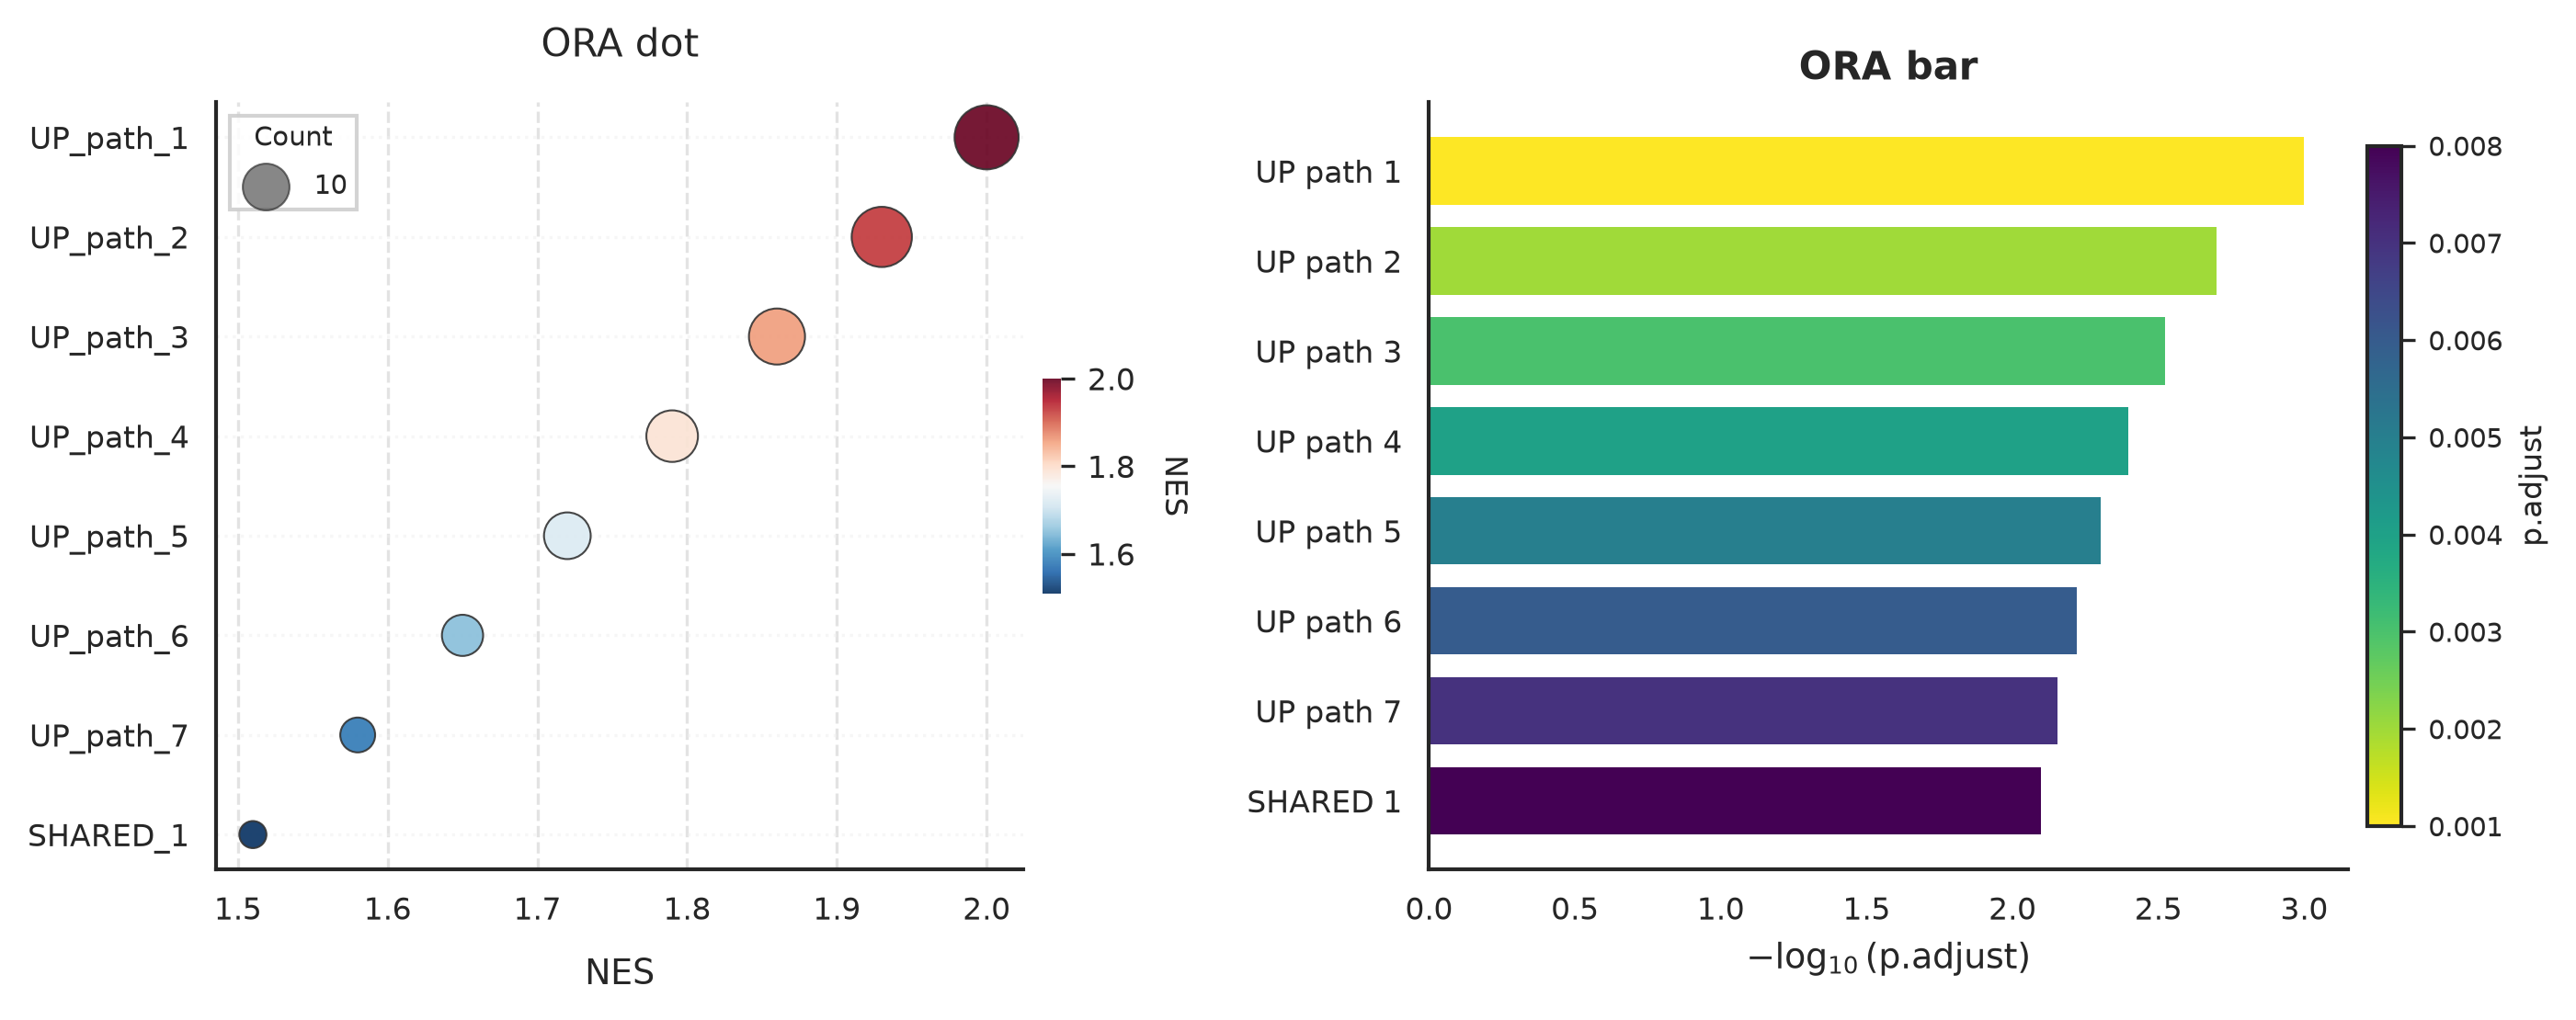

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), dpi=150)
scat.pl.enrich_dotplot(enrich_up, top_n=8, title="ORA dot", ax=axes[0], show=False, fontsize=9)
scat.pl.enrich_barplot(enrich_up, top_n=8, title="ORA bar", ax=axes[1], show=False, fontsize=9)
plt.tight_layout()
plt.show()

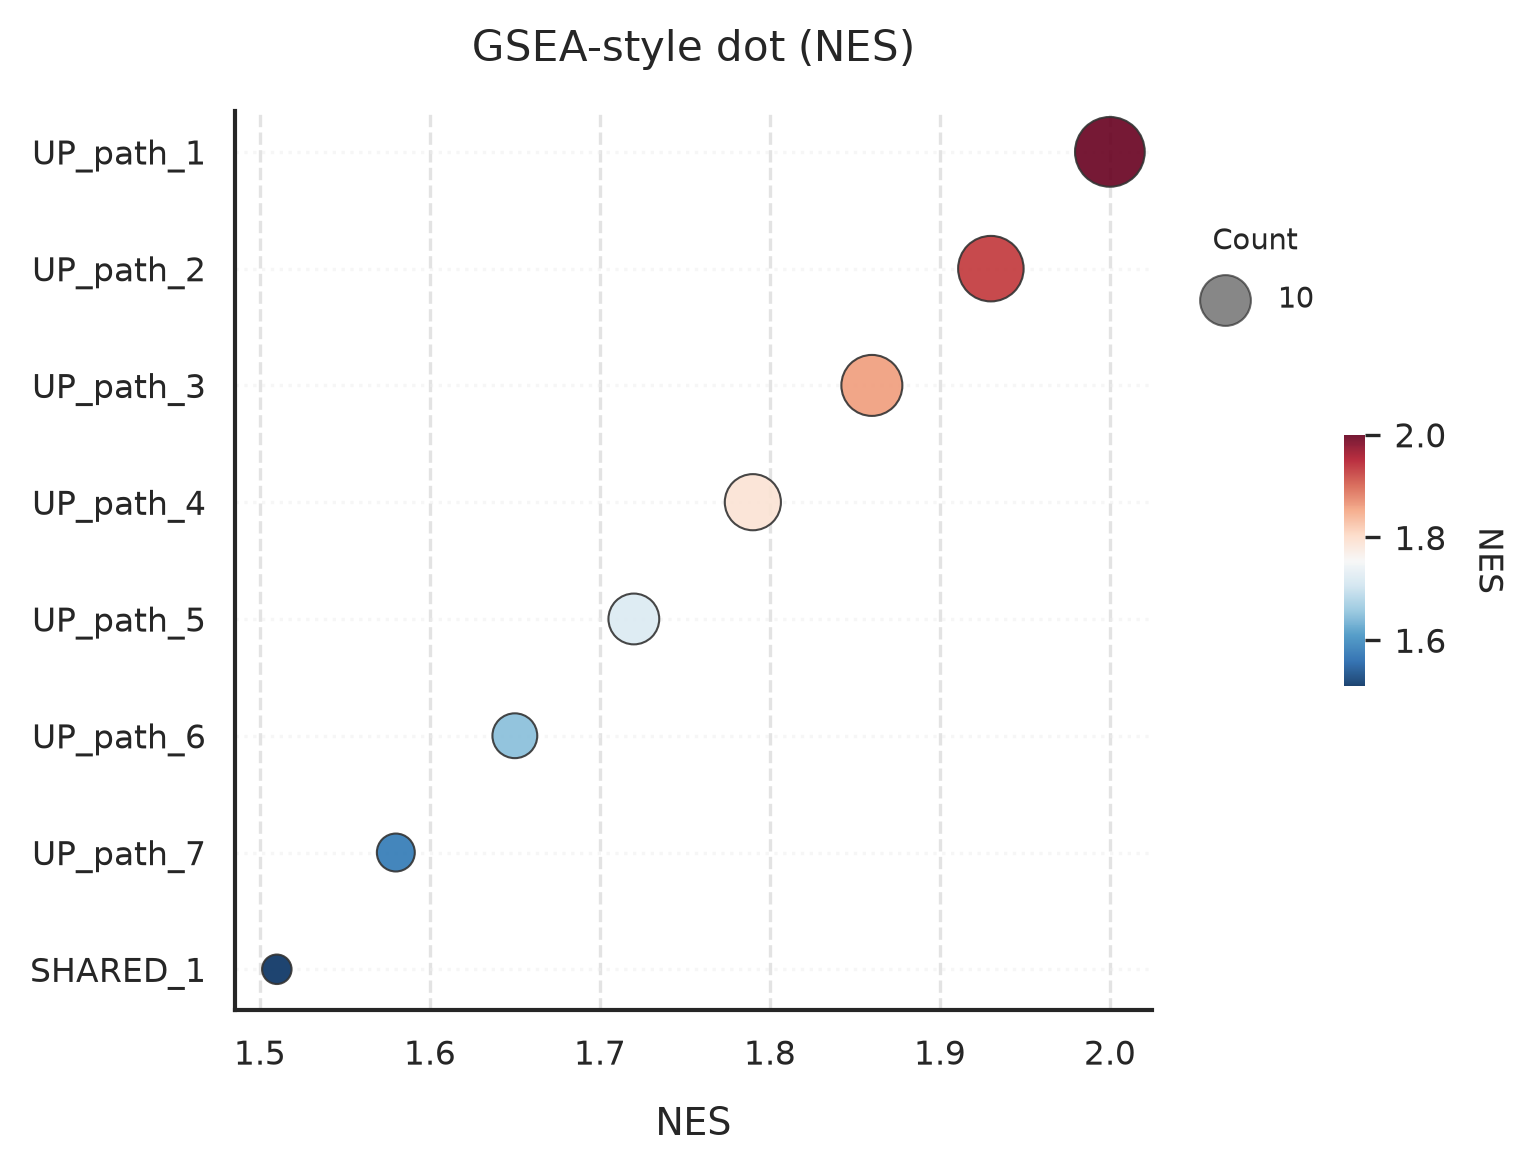

In [18]:
scat.pl.enrich_dotplot(
    enrich_up,
    top_n=8,
    x="NES",
    color_by="NES",
    title="GSEA-style dot (NES)",
    figsize=(5.0, 3.8),
    dpi=150,
    fontsize=9,
    show=True,
);

### Multi-group comparison dot plot (compareCluster)

**What it answers:** which enriched terms dominate *each* group, in the classic
clusterProfiler `compareCluster` grid — the third multi-group view alongside
UpSet and Venn.

**Function**: `compare_dotplot` — **groups are columns** (x-axis), **terms are
rows** (y-axis), a dot at each enriched (group, term) cell; size = `GeneRatio`,
color = `p.adjust`. Terms shared across groups (the `SHARED_*` set here) line up
on one row with a dot in each column. On real data this is exactly how you
compare **GO vs. KEGG** or up- vs. down-regulated enrichment (see
{doc}`t_ec_standalone_de_enrichment`).

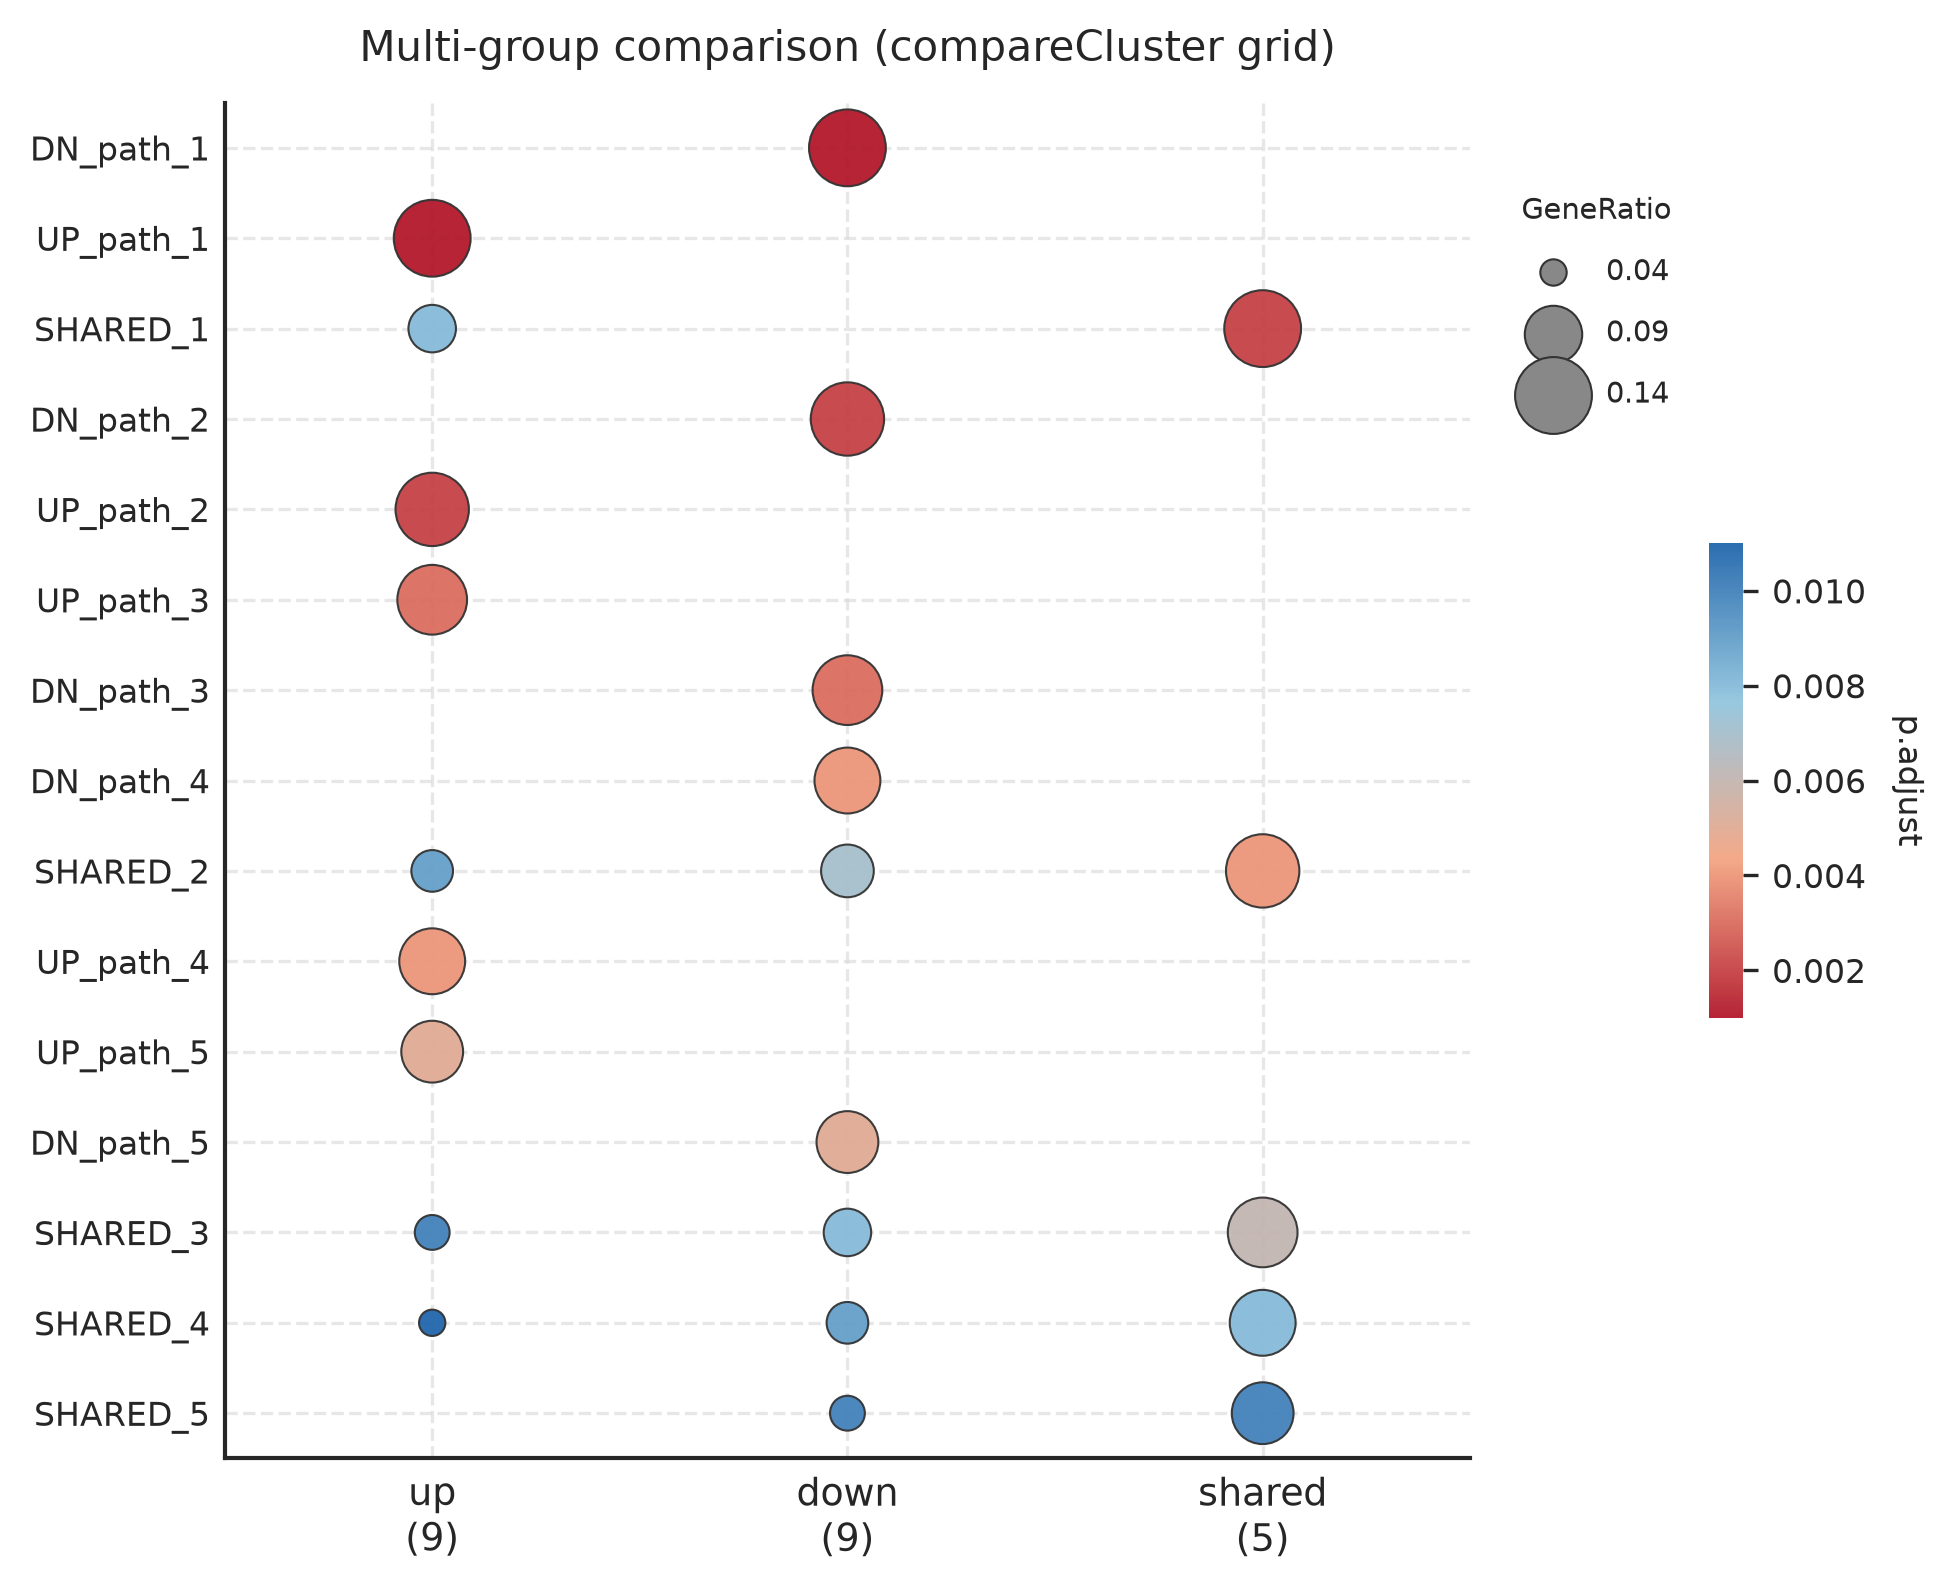

In [19]:
scat.pl.compare_dotplot(
    enrich_cmp,  # up / down / shared clusters (compare-style table)
    top_n=5,  # top terms per group
    title="Multi-group comparison (compareCluster grid)",
    figsize=(6.4, 5.2),
    dpi=150,
    fontsize=9,
);

### Multi-group term overlap (UpSet + Venn)

**What it answers:** Which enriched terms are unique vs shared across gene
lists / contrasts?

**Functions**: `enrich_upsetplot`, `enrich_vennplot`  
Input: compare-style table with a `Cluster` column (as from
`compare_enrichment` / `concat_compare_results`).


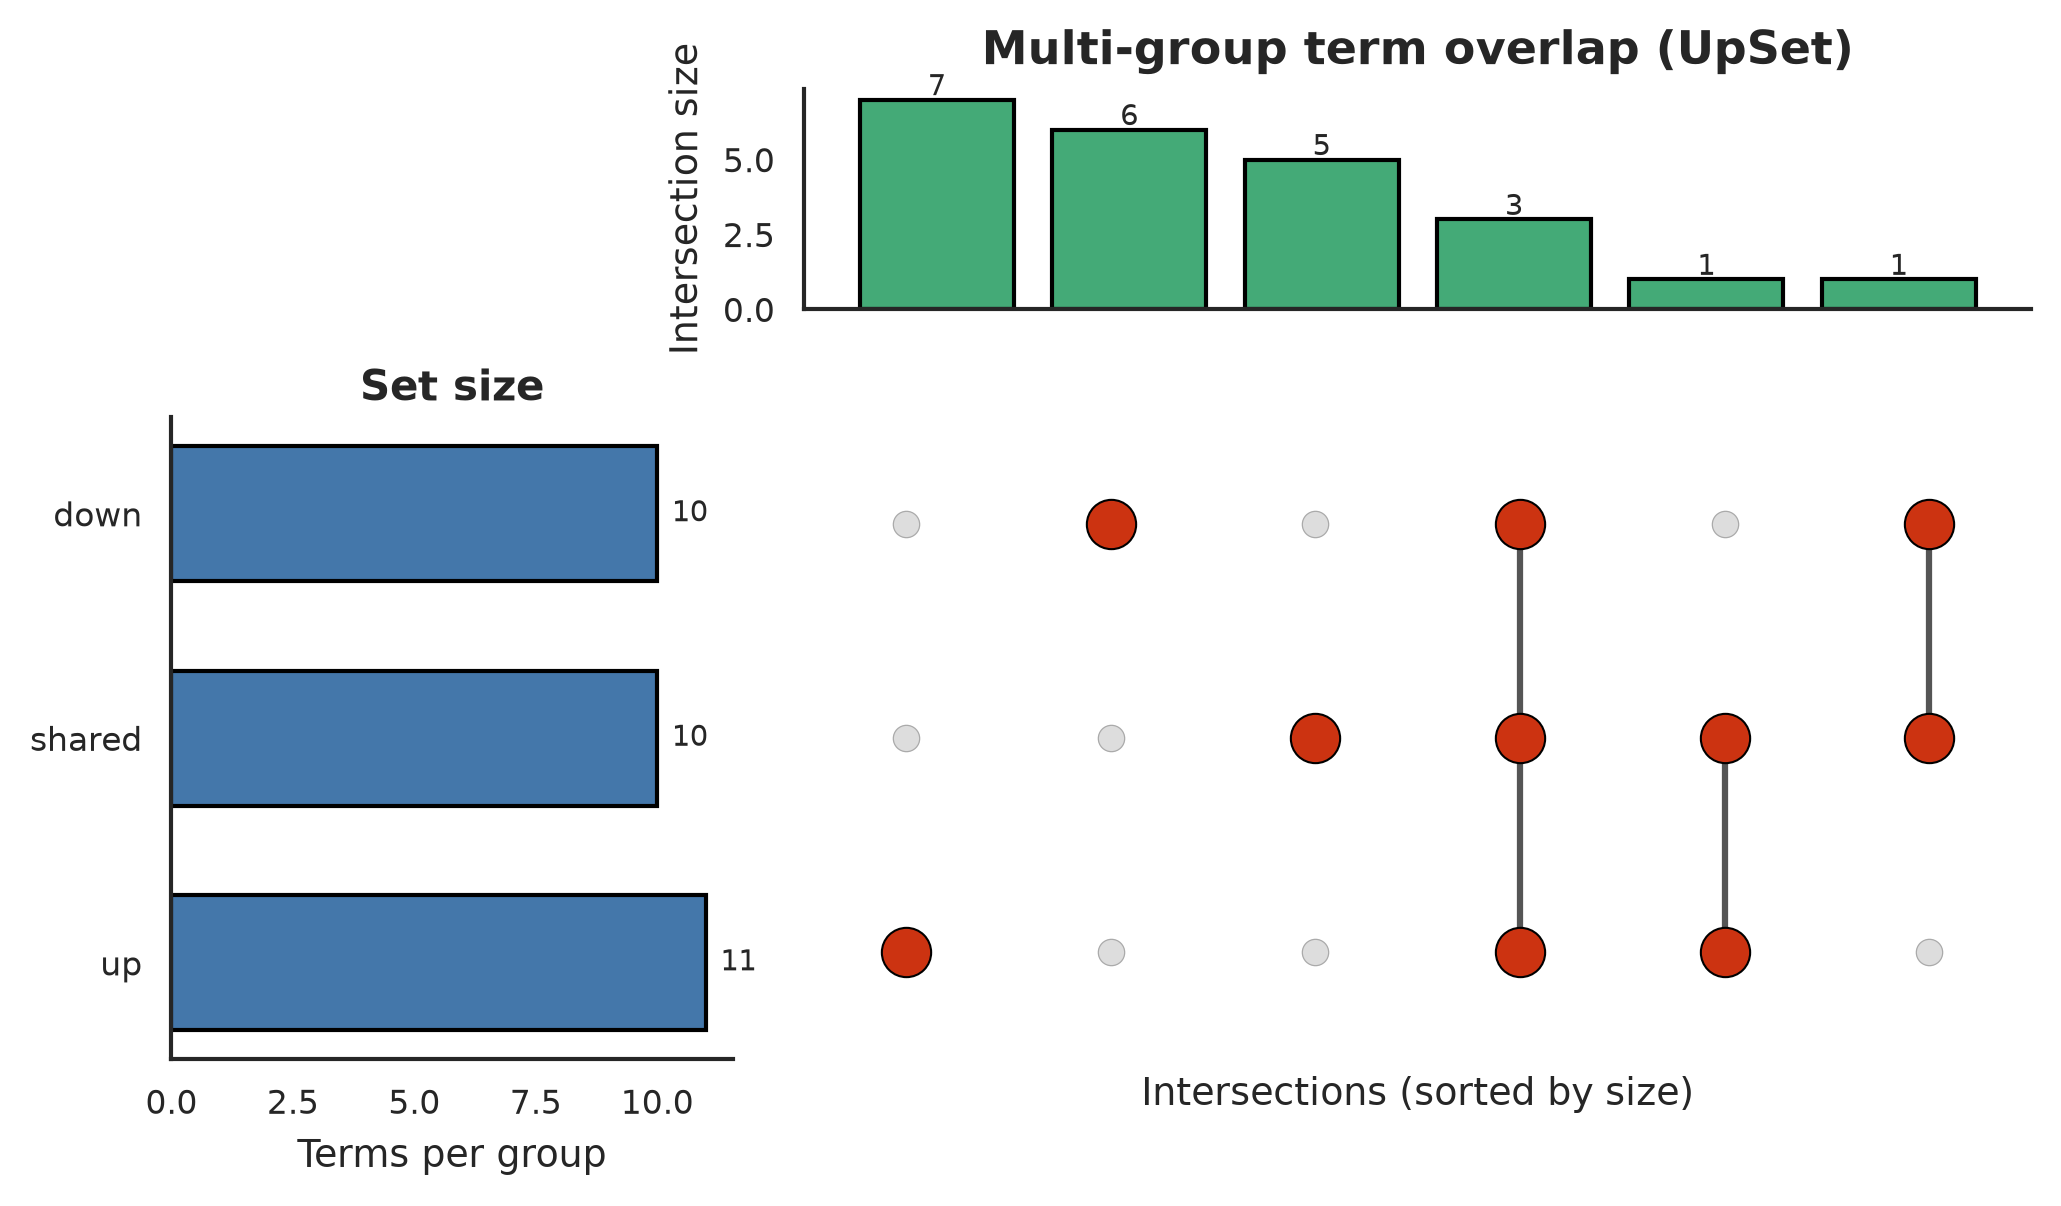

In [20]:
scat.pl.enrich_upsetplot(
    enrich_cmp,
    pval_cutoff=0.05,
    title="Multi-group term overlap (UpSet)",
    figsize=(8.0, 4.2),
    dpi=150,
    fontsize=9,
    show=True,
);

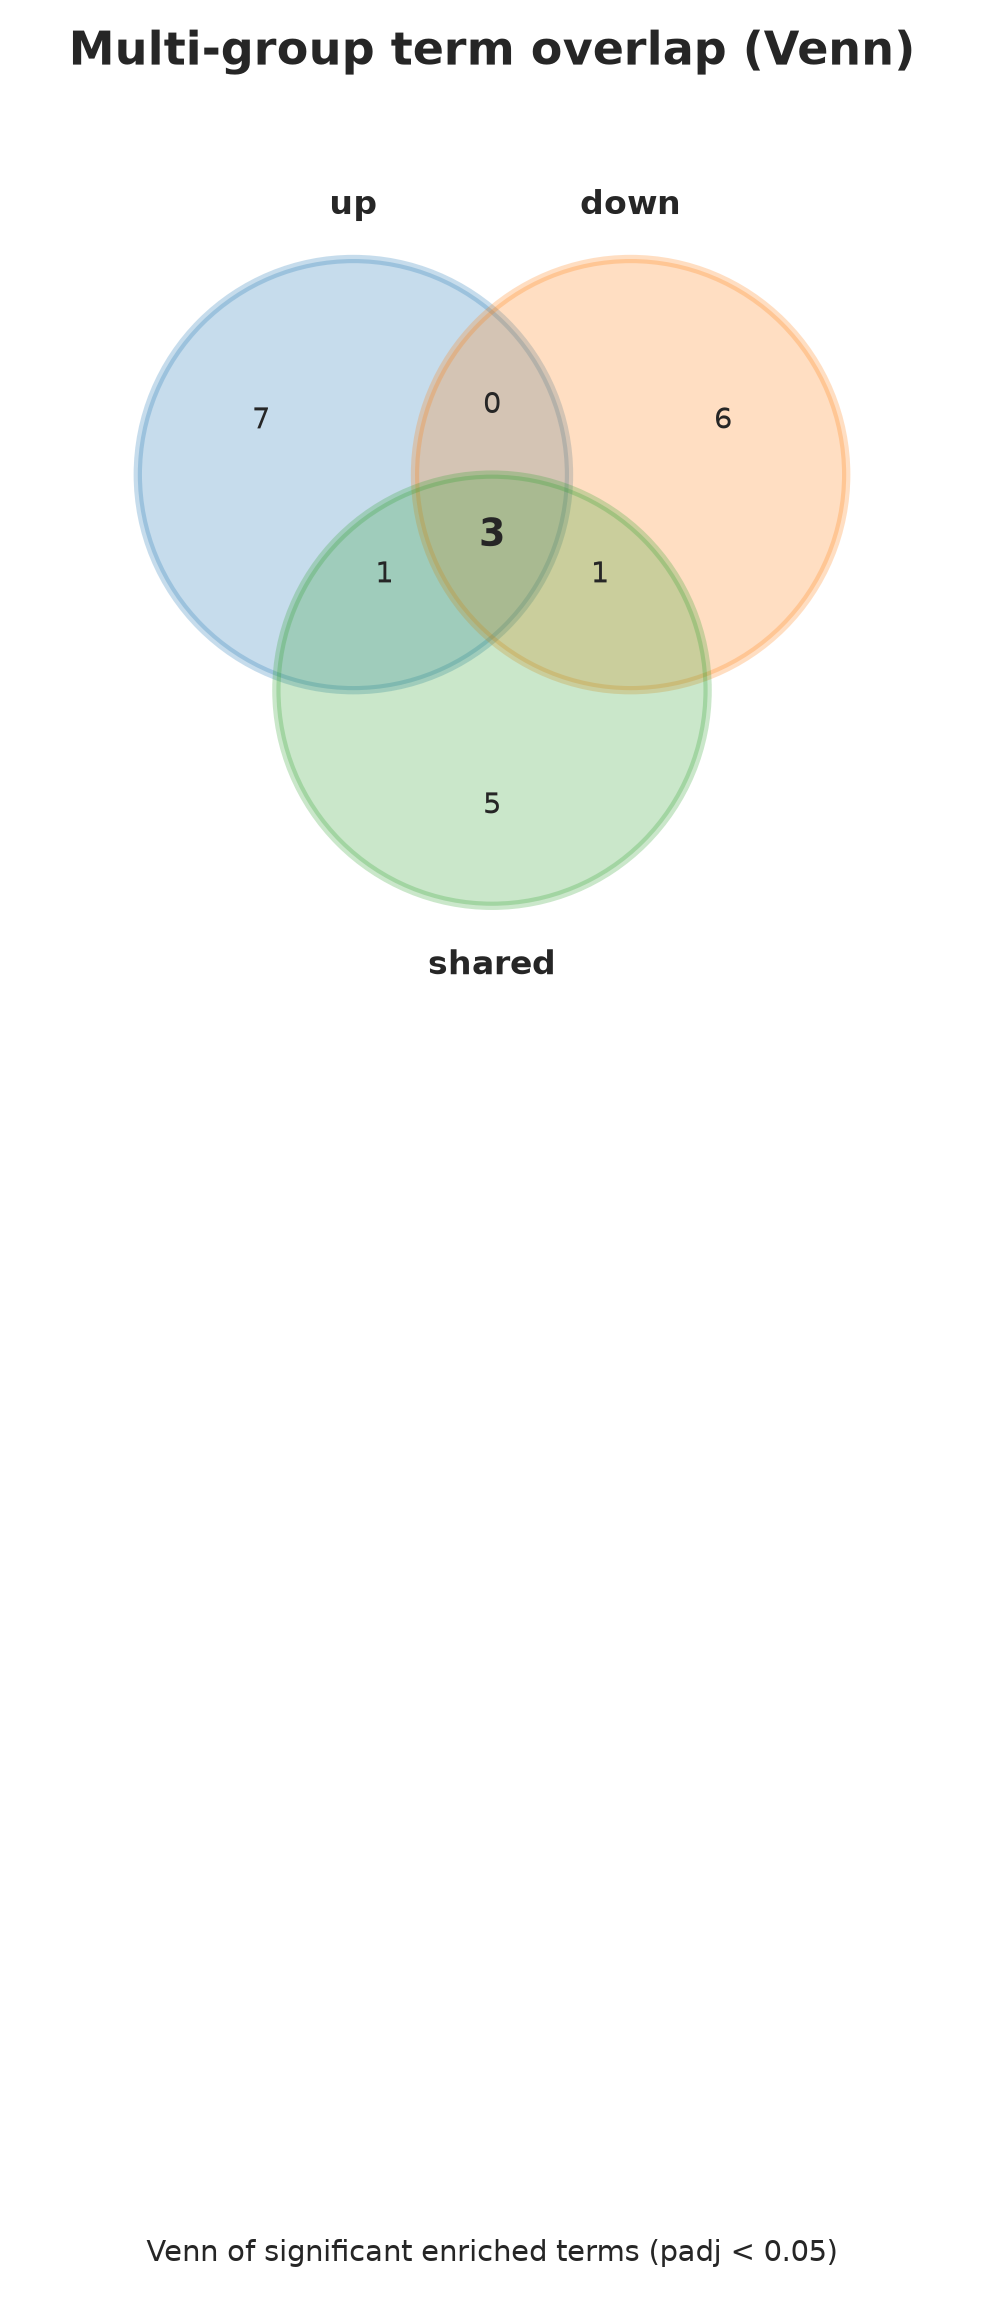

In [21]:
# Venn uses up to 4 groups; here three clusters
scat.pl.enrich_vennplot(
    enrich_cmp,
    pval_cutoff=0.05,
    title="Multi-group term overlap (Venn)",
    figsize=(5.0, 4.0),
    dpi=150,
    fontsize=9,
    show=True,
);

### Gene-level overlap (UpSet) + recoloring

**What it answers:** Which *genes* are called DE by several methods /
contrasts? Gene-level companion to the term-level `enrich_upsetplot` above.

**Functions**: `build_gene_membership`, `gene_upsetplot`, `common_genes`  
Input: a `{name: DataFrame}` dict where each table is indexed by gene with
`logFC` + `p_adj`/`p_val` — i.e. the `[1]` output of
`scat.differential_expression`, or any DE table you bring yourself
(see {doc}`t_ec_gene_upset` for the full gene-UpSet → enrichment walkthrough).

In [22]:
# Three DE-like tables over the same genes (mimic 3 methods/contrasts) by
# jittering logFC. In practice each is the [1] output of
# scat.differential_expression, or any gene-indexed DataFrame you already have.
rng = np.random.default_rng(0)


def _jitter(df, scale):
    out = df[["logFC", "p_adj"]].copy()
    out["logFC"] = out["logFC"] + rng.normal(0, scale, len(out))
    return out


de_tables = {
    "methodA": all_results[["logFC", "p_adj"]],
    "methodB": _jitter(all_results, 0.15),
    "methodC": _jitter(all_results, 0.30),
}
mem = scat.pl.build_gene_membership(
    de_tables,
    direction="separate",
    padj_cutoff=0.05,
    logfc_cutoff=0.35,
)
print("membership:", mem.shape, "| sets:", list(mem.columns))

membership: (437, 6) | sets: ['methodA::up', 'methodA::down', 'methodB::up', 'methodB::down', 'methodC::up', 'methodC::down']


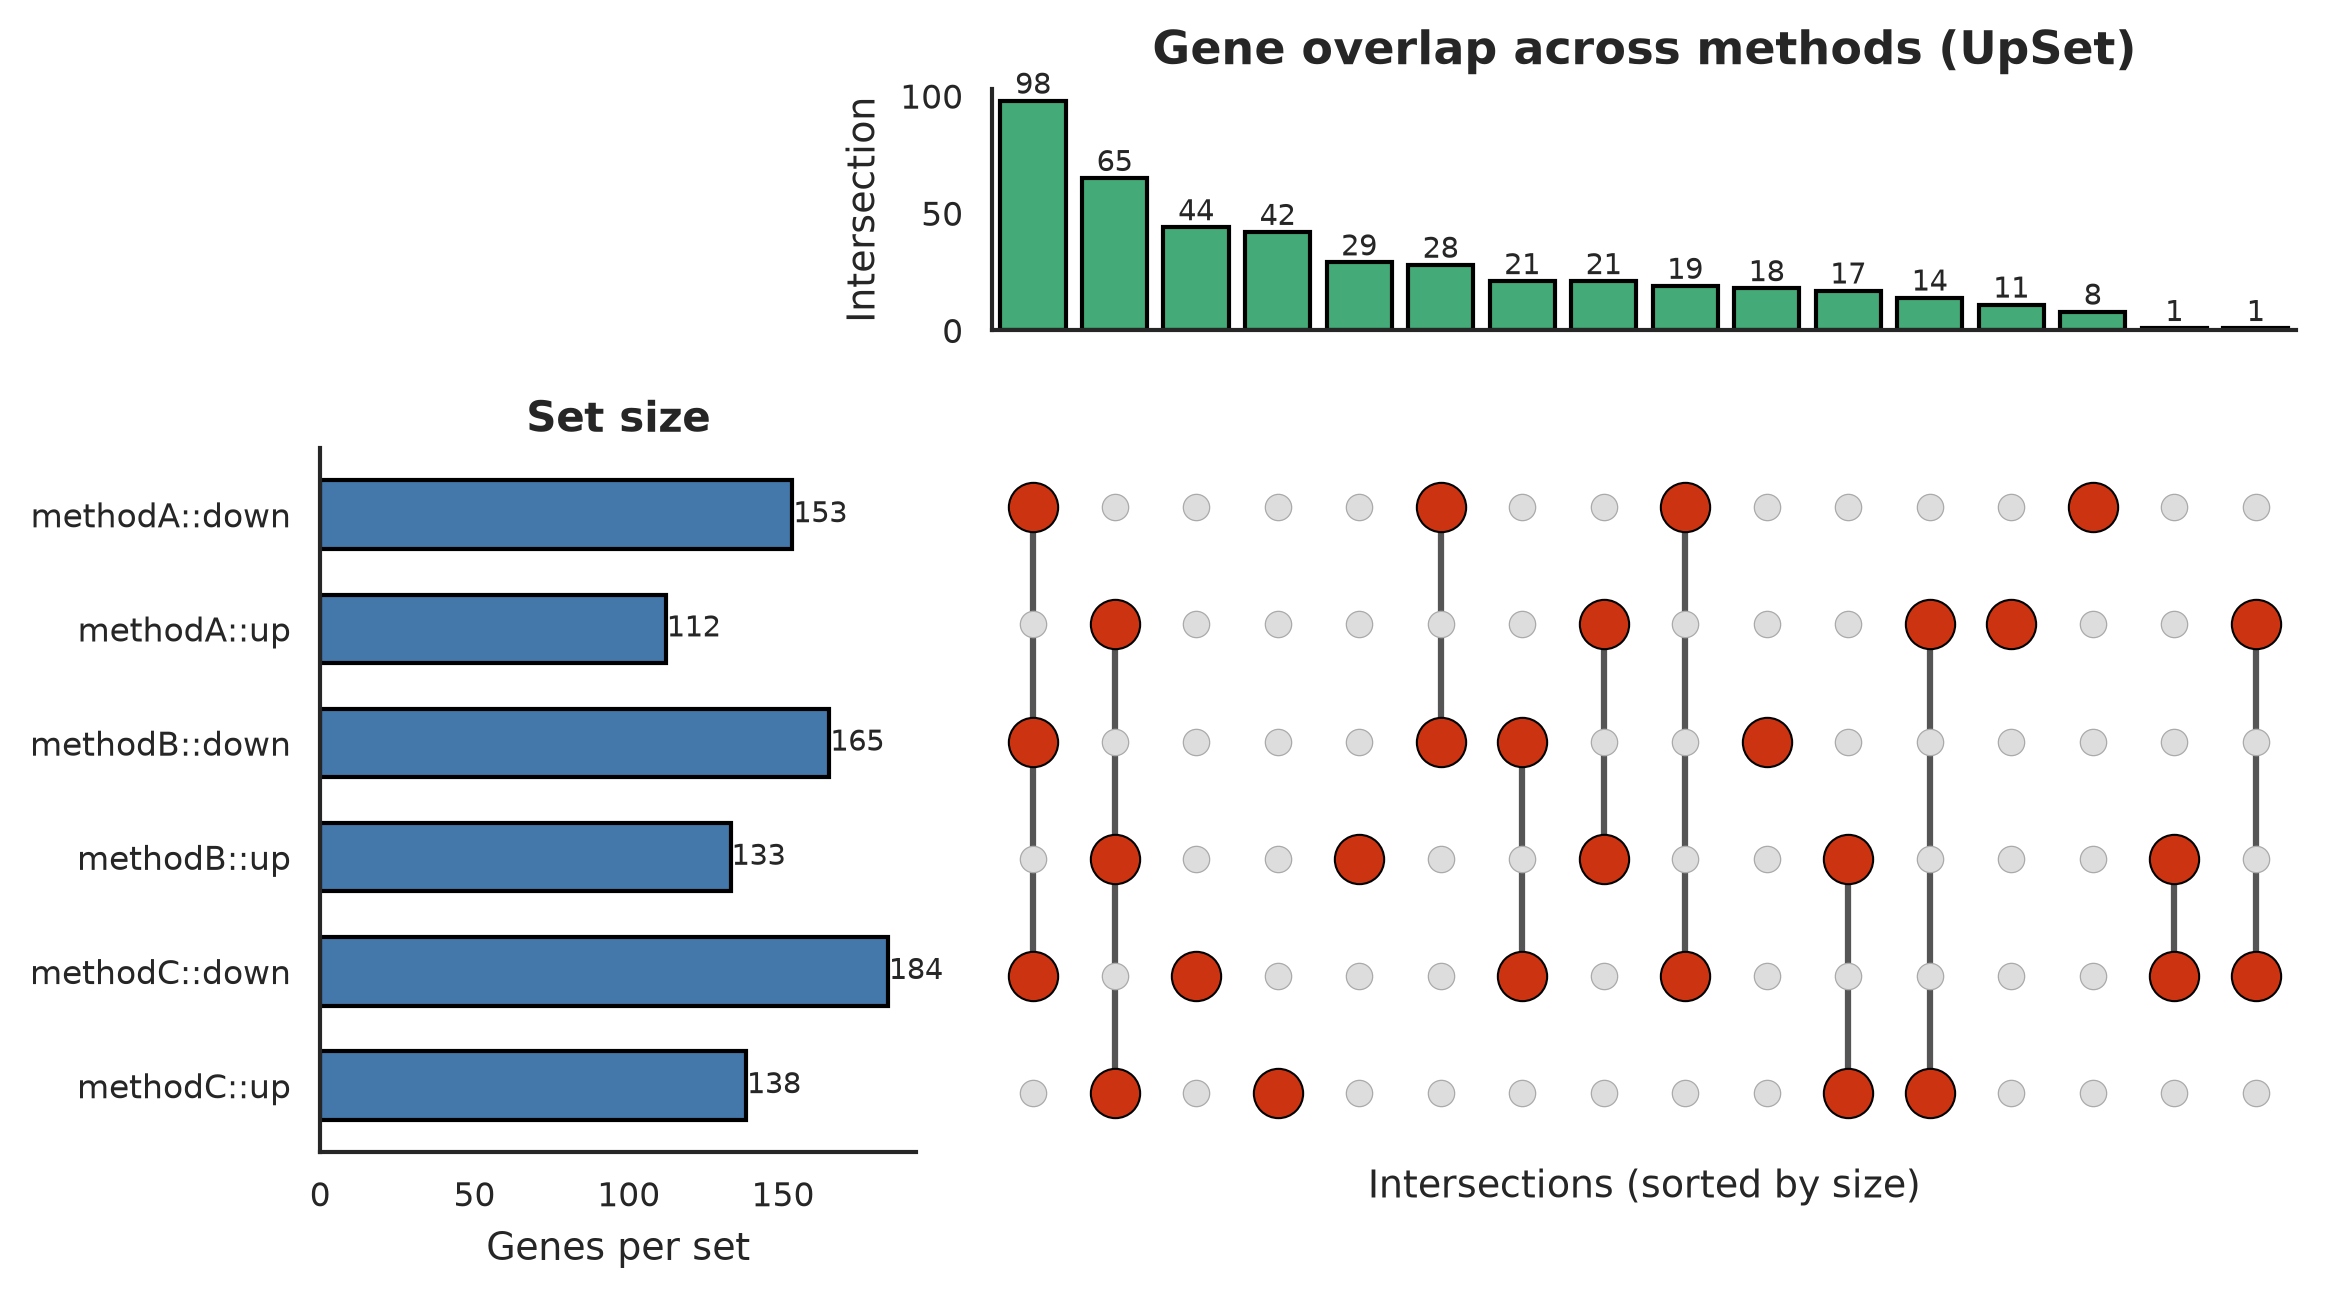

In [23]:
scat.pl.gene_upsetplot(
    membership=mem,
    title="Gene overlap across methods (UpSet)",
    figsize=(8.5, 4.6),
    dpi=150,
    fontsize=9,
    show=True,
);

**Variant — recolor every element.** `set_color`, `intersection_color`,
`dot_color`, `inactive_color` and `line_color` each take any matplotlib color;
`intersection_color` / `dot_color` also accept a **per-column list** to
highlight specific intersections. (These palette kwargs recur across the
`scat.pl` plots — e.g. `enrich_upsetplot` uses the same names.)

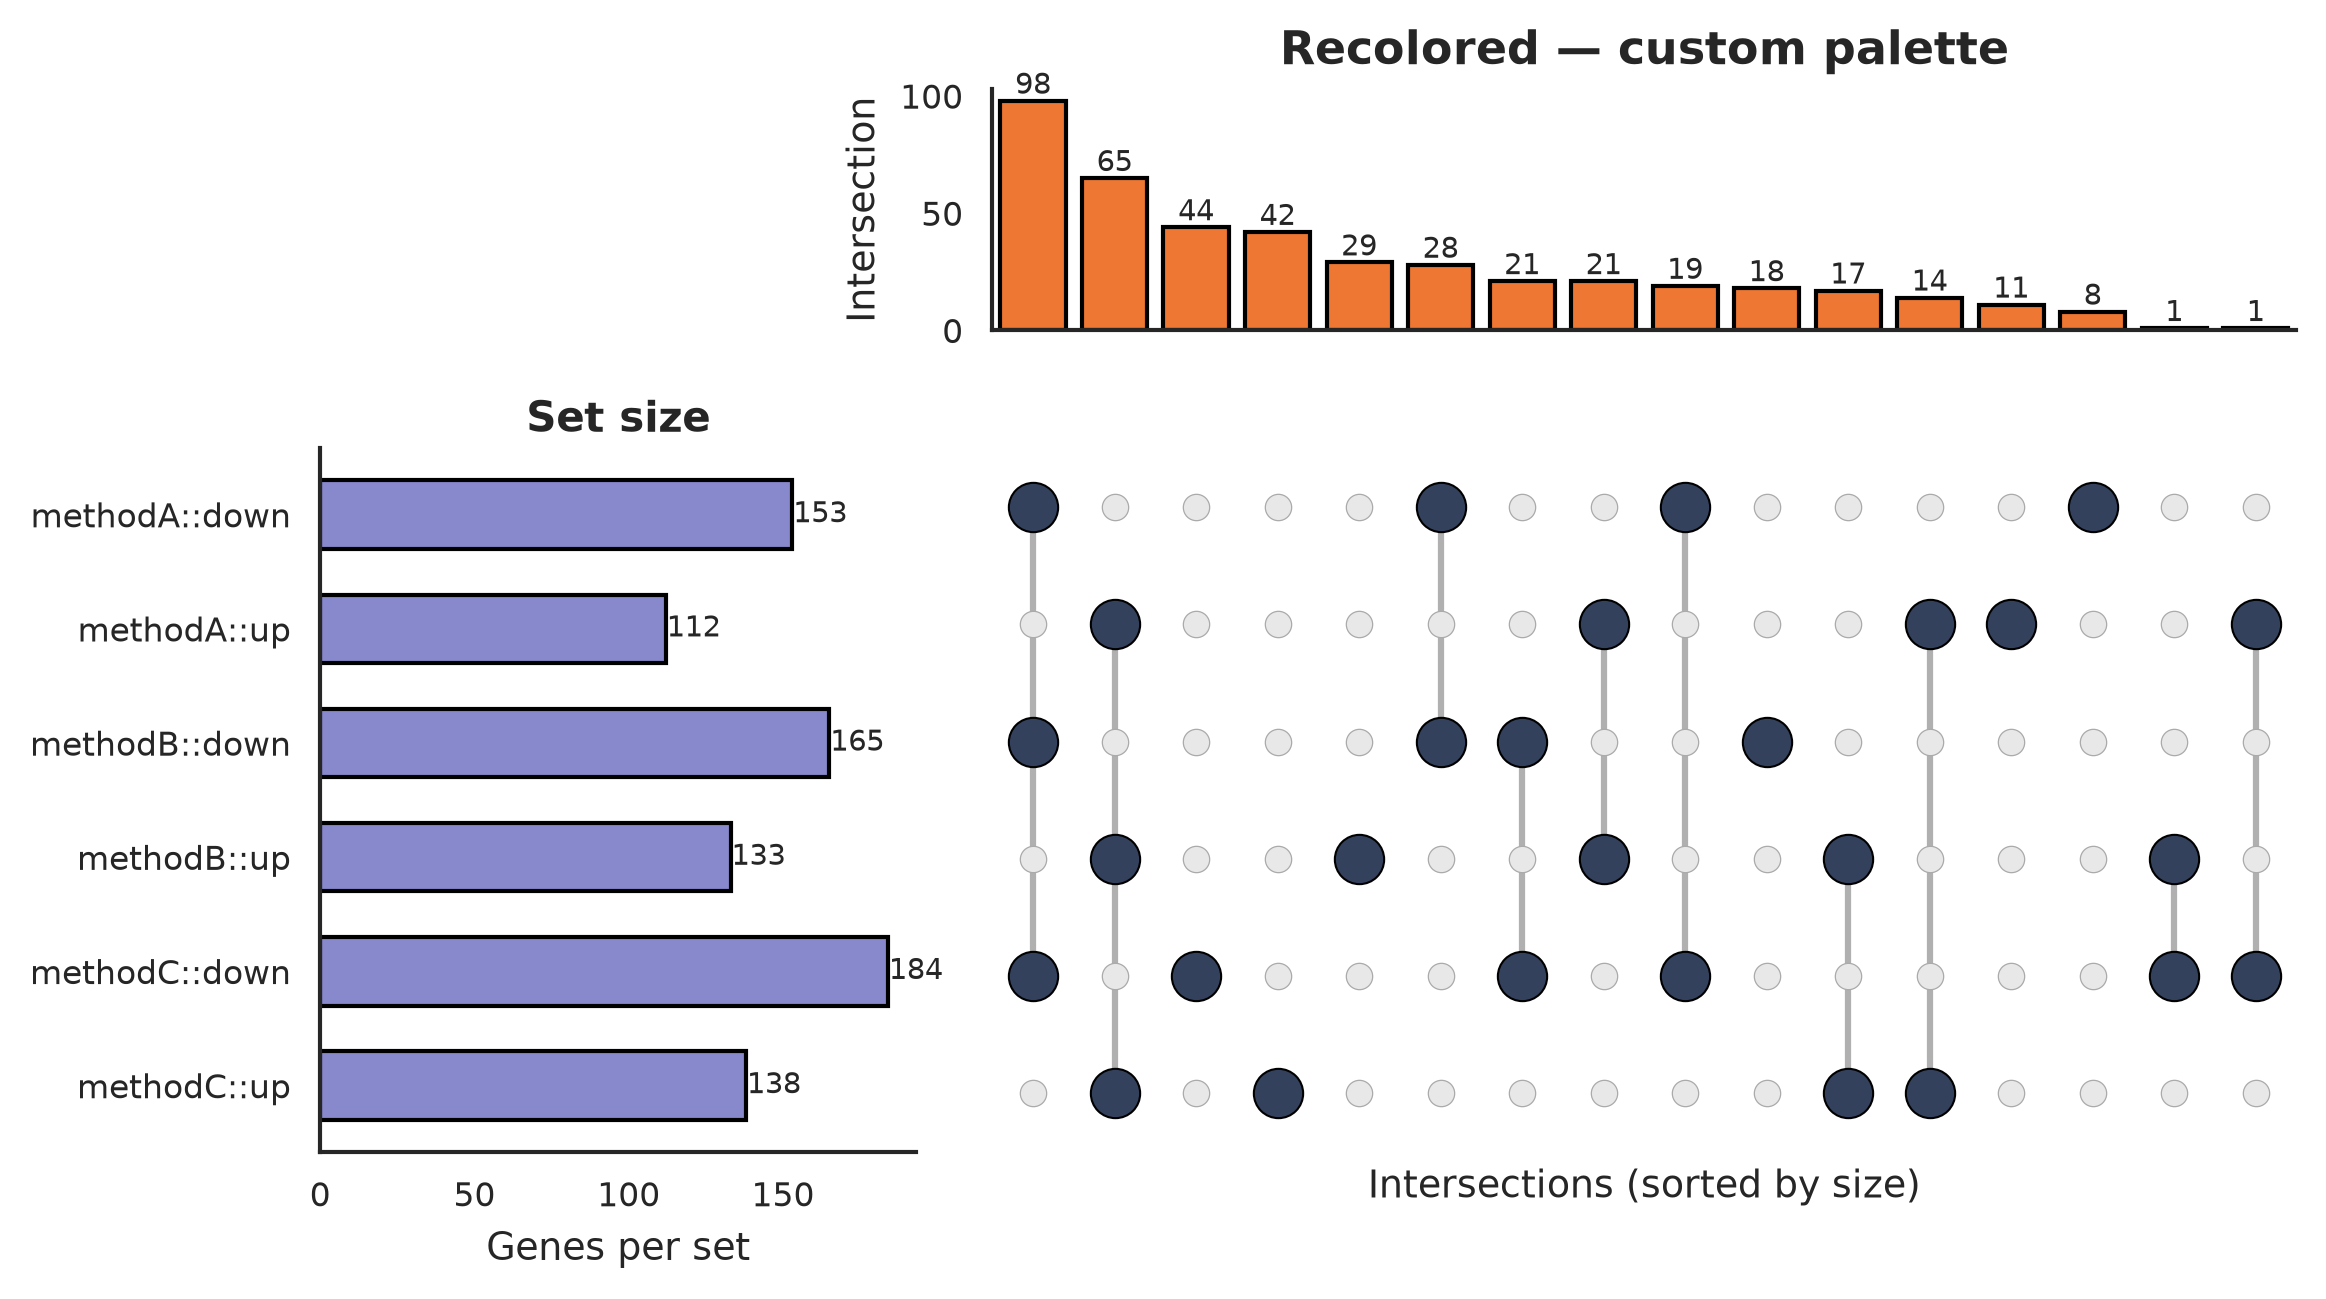

common-up genes: 65


In [24]:
scat.pl.gene_upsetplot(
    membership=mem,
    title="Recolored — custom palette",
    set_color="#8888CC",
    intersection_color="#EE7733",
    dot_color="#33415C",
    inactive_color="#E8E8E8",
    line_color="#B0B0B0",
    figsize=(8.5, 4.6),
    dpi=150,
    fontsize=9,
    show=True,
)

# Bridge to enrichment: genes up in *every* method → run_enrichment(...).
up = scat.pl.common_genes(mem, direction="up")
print("common-up genes:", len(up))

### GSEA running-sum

**Function**: `gseaplot` (+ in-memory `run_gsea`)


2026-07-25 08:28:22,348 [WARNING] Duplicated values found in preranked stats: 0.07% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


             Term       NES  pvalue  p.adjust
0  Planted_up_set  2.822078     0.0       0.0


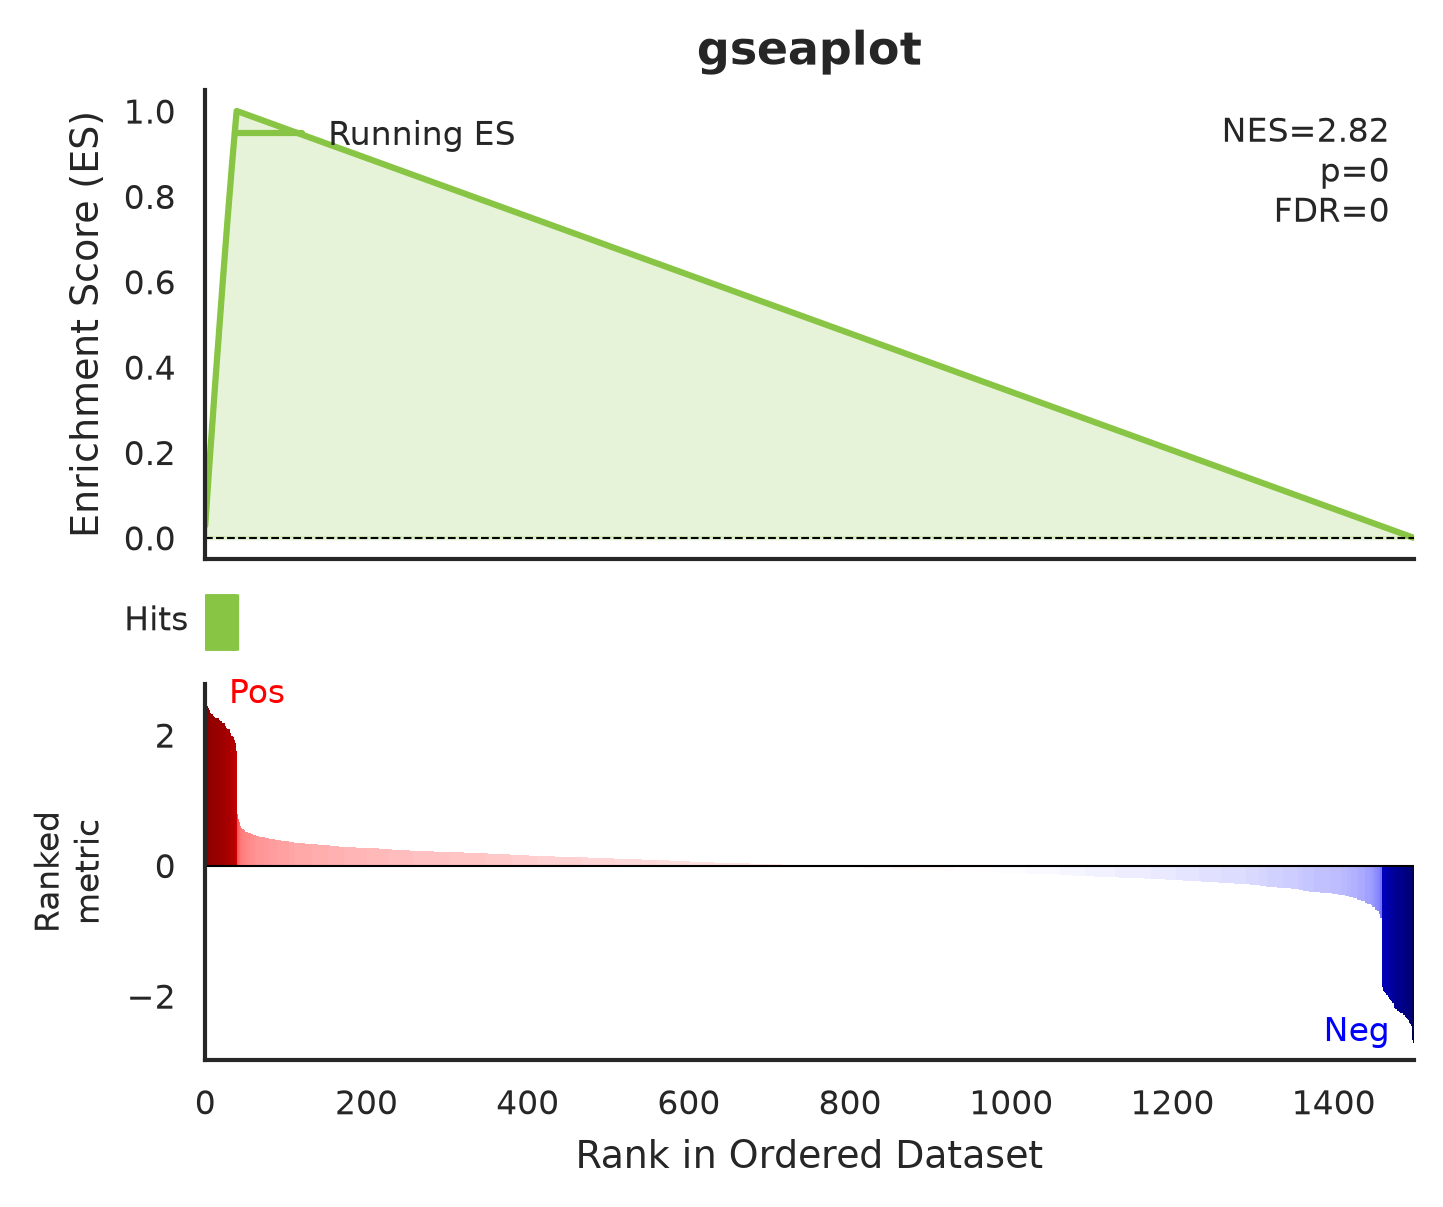

In [25]:
ranked = all_results["logFC"].dropna().sort_values(ascending=False)
demo_set = {"Planted_up_set": list(ranked.index[:40])}
gsea_res = scat.run_gsea(
    ranked,
    gene_sets=demo_set,
    organism="mouse",
    nperm=100,
    min_size=10,
    max_size=80,
    verbose=False,
)
cols = [c for c in ("Term", "NES", "pvalue", "p.adjust") if c in gsea_res.columns]
print(gsea_res[cols].head() if len(gsea_res) else gsea_res)
if len(gsea_res) > 0:
    scat.pl.gseaplot(
        ranked,
        gsea_result=gsea_res,
        term=str(gsea_res.iloc[0]["Term"]),
        title="gseaplot",
        figsize=(5.2, 4.2),
        dpi=150,
        show=True,
    )
else:
    print("GSEA empty; skip.")

## 7. Multi-panel layout and export

Compact 2×2 with small labels; legends use `legend_position="UR"` where applicable.


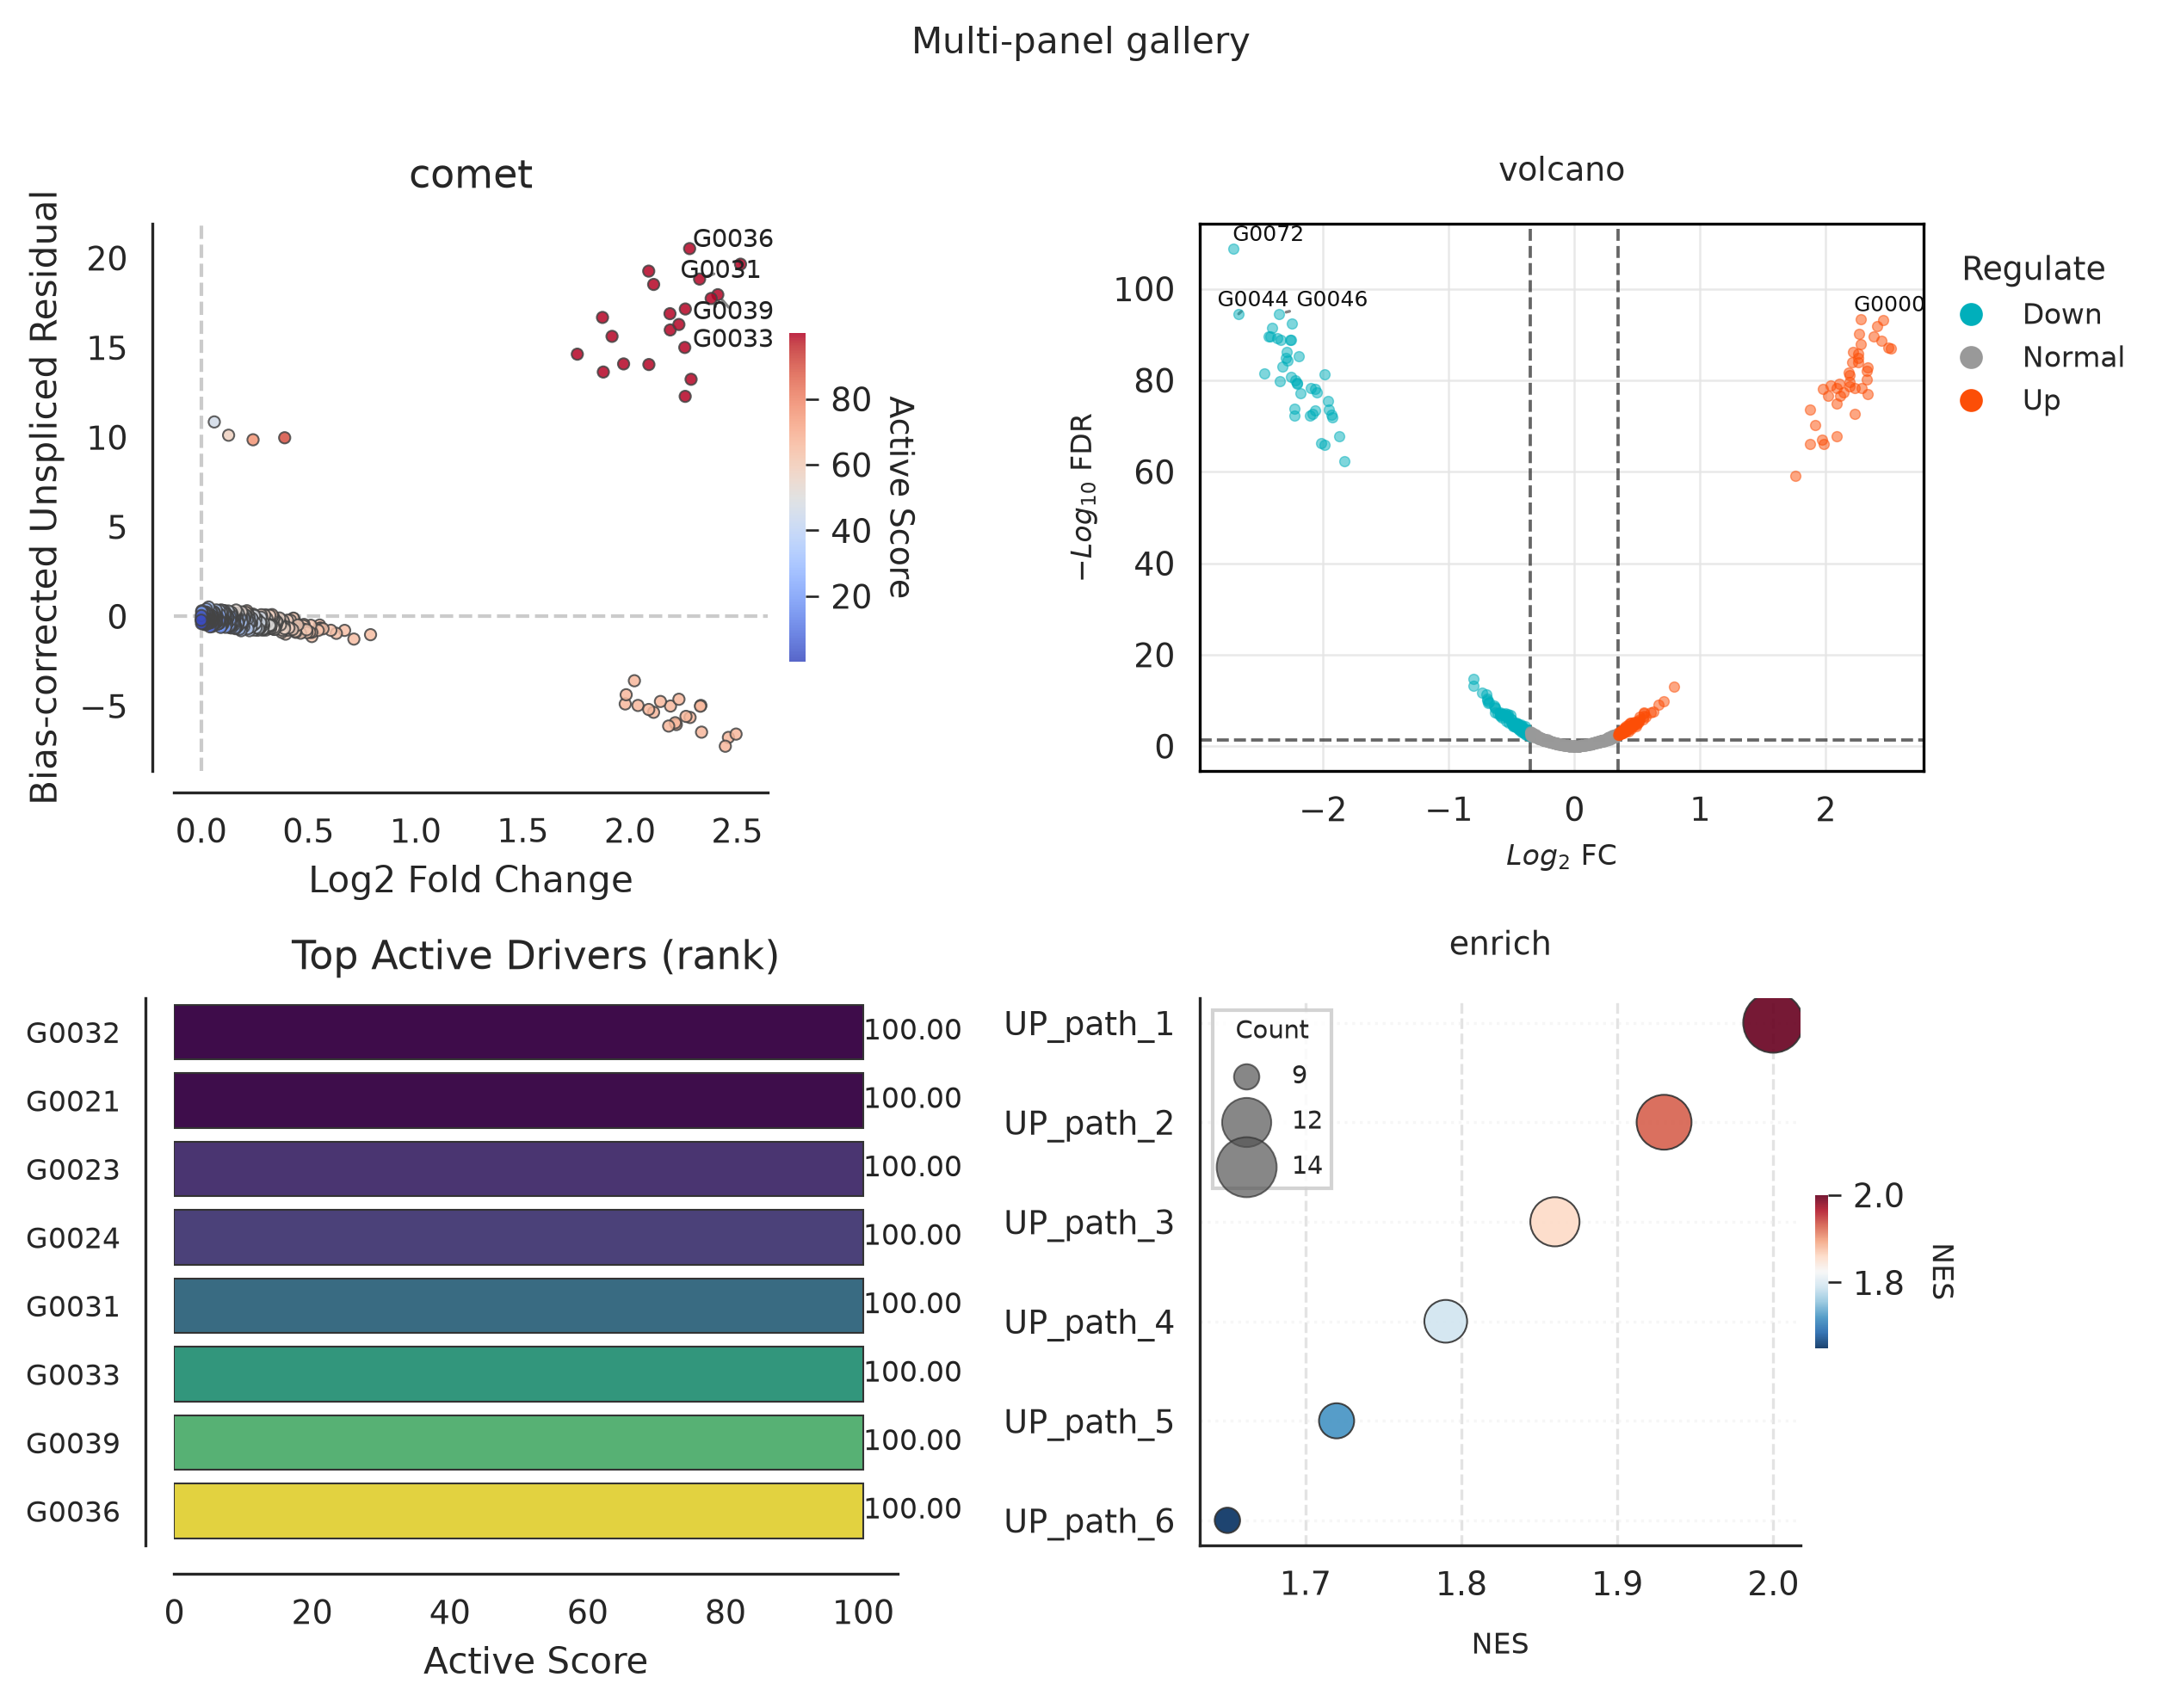

In [26]:
with scat.pl.style_context(linewidth=0.8, labelsize=8, titlesize=9, legendsize=7):
    fig, axes = plt.subplots(2, 2, figsize=(8.5, 6.5), dpi=150)
    scat.pl.comet_plot(all_results, top_n=4, s=10, title="comet", ax=axes[0, 0], show=False, **FS)
    scat.pl.volcano_plot(
        all_results,
        style="ggvolcano",
        title="volcano",
        legend_position="UR",
        ax=axes[0, 1],
        show=False,
        top_n=4,
        s=8,
        alpha=0.5,
        fontsize=8,
        label_fontsize=6,
        logfc_cutoff=0.35,
        pval_cutoff=0.05,
    )
    scat.pl.active_score_rankplot(all_results, top_n=8, ax=axes[1, 0], show=False)
    scat.pl.enrich_dotplot(
        enrich_up, top_n=6, title="enrich", ax=axes[1, 1], show=False, fontsize=8
    )
    fig.suptitle("Multi-panel gallery", y=1.01, fontsize=10)
    plt.tight_layout()
    plt.show()

In [27]:
from pathlib import Path
import tempfile

export_dir = Path(tempfile.mkdtemp(prefix="scatrans_pl_gallery_"))
fig1, _ = scat.pl.comet_plot(all_results, top_n=4, s=10, show=False, **FS, **FIG)
fig2, _ = scat.pl.volcano_plot(all_results, style="ggvolcano", show=False, **VOLC)
scat.pl.save_all_figures(
    {"01_comet": fig1, "02_volcano": fig2},
    directory=str(export_dir),
    dpi=150,
    fmt="png",
    close=True,
)
print("exported to", export_dir)
print(sorted(p.name for p in export_dir.glob("*")))


exported to /tmp/scatrans_pl_gallery_fcw8ilzp
['01_comet.png', '02_volcano.png']


## 8. Quick map

| Question | Function | Input |
|----------|----------|--------|
| DE × residual drivers | `comet_plot` | full `all_results` |
| Two-sided volcano | `volcano_plot(style="ggvolcano")` | full `all_results` |
| Top scores | `active_score_rankplot` | `all_results` |
| Bias / γ QC | `bias_diagnostic_plot`, `gamma_shrinkage_plot` | `all_results` |
| U/S check | `velocity_phase_portraits` | `adata` + genes |
| ORA dots/bars | `enrich_dotplot`, `enrich_barplot` | enrich table |
| **Multi-list overlap** | `enrich_upsetplot`, `enrich_vennplot` | table with `Cluster` |
| GSEA curve | `gseaplot` | ranks + `run_gsea` |

**Next:** {doc}`../user_guide/plotting` · {doc}`t_ec_active_transcription` ·
{doc}`t_ec_standalone_de_enrichment` · {doc}`../statistical_guidance`
